# Gradient Boosting Machines (GBMs) with XGBoost

The following topics are covered in this tutorial:

- Downloading a real-world dataset from a Kaggle competition
- Performing feature engineering and prepare the dataset for training
- Training and interpreting a gradient boosting model using XGBoost
- Training with KFold cross validation and ensembling results
- Configuring the gradient boosting model and tuning hyperparamters

In [3]:
!pip list  grep xgboost

Package                           Version
--------------------------------- ------------------
aext-assistant                    4.0.15
aext-assistant-server             4.0.15
aext-core                         4.0.15
aext-core-server                  4.0.15
aext-panels                       4.0.15
aext-panels-server                4.0.15
aext-share-notebook               4.0.15
aext-share-notebook-server        4.0.15
aext-shared                       4.0.15
aiobotocore                       2.12.3
aiohttp                           3.9.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
alembic                           1.16.4
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.3
anaconda-project                  0.11.1
annotated-t

In [3]:
import xgboost
print(xgboost.__version__)

3.0.2


In [4]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\aa\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


In [ ]:
!pip install jovian opendatasets xgboost graphviz lightgbm scikit-learn xgboost lightgbm --upgrade --quiet

## Problem Statement

This tutorial takes a practical and coding-focused approach. We'll learn gradient boosting by applying it to a real-world dataset from the [Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales) competition on Kaggle:

> Rossmann operates over 3,000 drug stores in 7 European countries. Currently, Rossmann store managers are tasked with predicting their daily sales for up to six weeks in advance. Store sales are influenced by many factors, including promotions, competition, school and state holidays, seasonality, and locality. 
>
>
> With thousands of individual managers predicting sales based on their unique circumstances, the accuracy of results can be quite varied. You are provided with historical sales data for 1,115 Rossmann stores. The task is to forecast the "Sales" column for the test set. Note that some stores in the dataset were temporarily closed for refurbishment.
>
> View and download the data here: https://www.kaggle.com/c/rossmann-store-sales/data

## Downloading the Data

We can download the dataset from Kaggle directly within the Jupyter notebook using the `opendatasets` library. Make sure to [accept the competition rules](https://www.kaggle.com/c/rossmann-store-sales/rules) before executing the following cell.

In [9]:
import os
import opendatasets as od
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [10]:
od.download('https://www.kaggle.com/c/rossmann-store-sales')

Skipping, found downloaded files in ".\rossmann-store-sales" (use force=True to force download)


You'll be asked to provide your Kaggle credentials to download the data. Follow these instructions: http://bit.ly/kaggle-creds

In [14]:
os.listdir('rossmann-store-sales')

['store.csv', 'submission.csv', 'test.csv', 'train.csv']

In [16]:
ross_df = pd.read_csv('./rossmann-store-sales/train.csv', low_memory=False)
store_df = pd.read_csv('./rossmann-store-sales/store.csv')
test_df = pd.read_csv('./rossmann-store-sales/test.csv')
submission_df = pd.read_csv('./rossmann-store-sales/submission.csv')

In [18]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [20]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [22]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


> **EXERCISE**: Read the data description provided on the competition page to understand what the values in each column of `store_df` represent.

Let's merge the information from `store_df` into `train_df` and `test_df`.

In [26]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_test_df = test_df.merge(store_df, how='left', on='Store')

> **EXERCISE**: Perform exploratory data analysis and visualization on the dataset. Study the distribution of values in each column, and their relationship with the target column `Sales`.

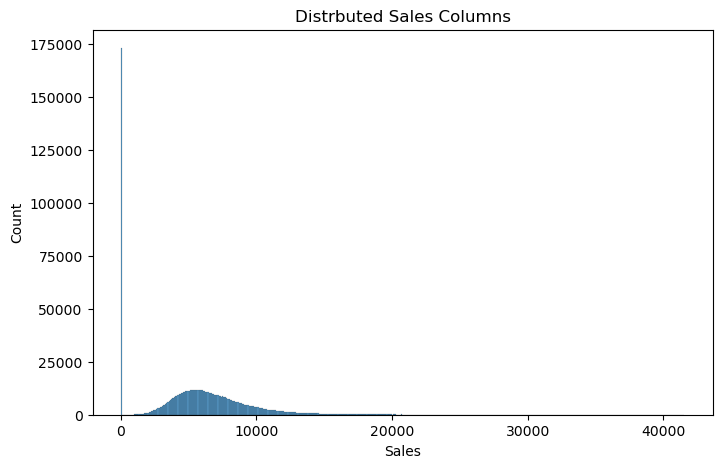

In [29]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted Sales Columns')
sns.histplot(data = merged_df, x = 'Sales')
plt.show()
#  النماذج الخطيه صعب ان تتعلم من هذا التوزيع

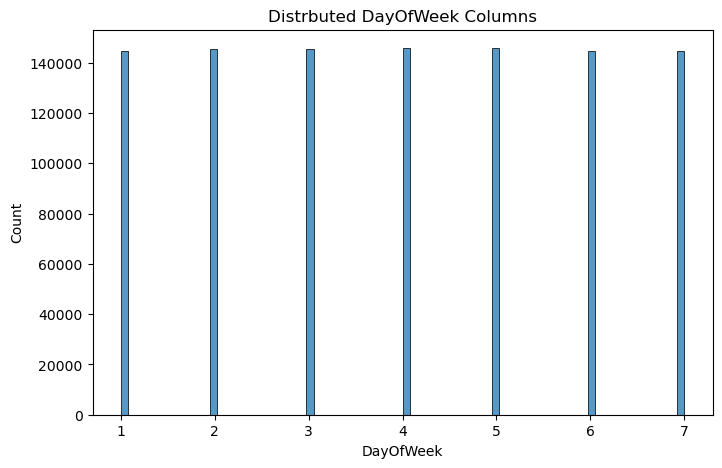

In [30]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted DayOfWeek Columns')
sns.histplot(data = merged_df, x = 'DayOfWeek')
plt.show()

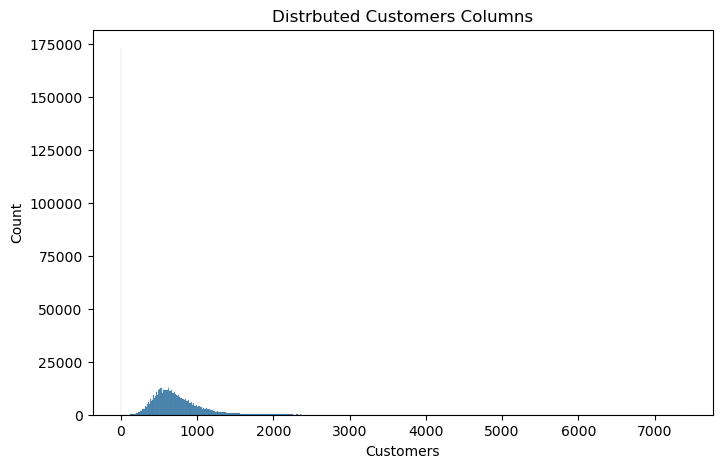

In [31]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted Customers Columns')
sns.histplot(data = merged_df, x = 'Customers')
plt.show()

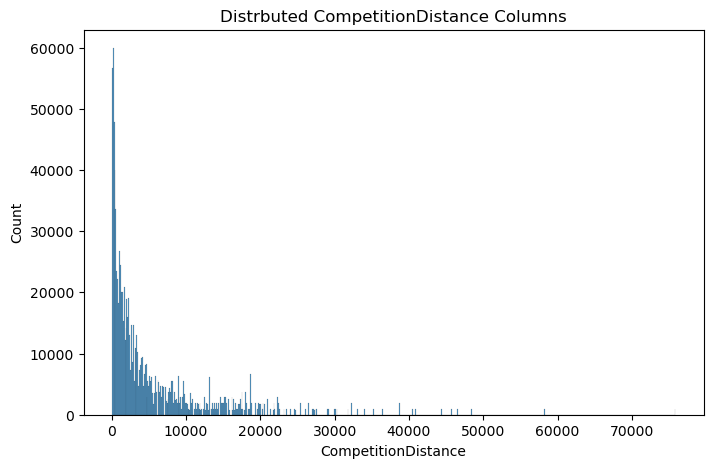

In [32]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted CompetitionDistance Columns')
sns.histplot(data = merged_df, x = 'CompetitionDistance')
plt.show()

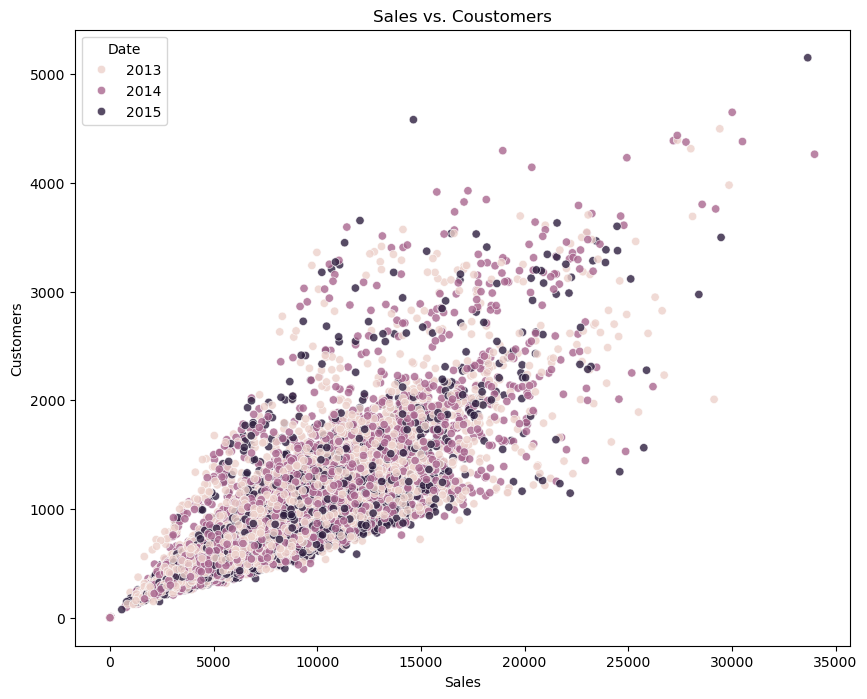

In [33]:
plt.figure(figsize = (10, 8))
temp_df = merged_df.sample(40000)
plt.title('Sales vs. Coustomers')
sns.scatterplot(data = temp_df, x = temp_df.Sales, y = temp_df.Customers, hue = pd.to_datetime(temp_df.Date).dt.year, alpha = 0.8)
plt.show()

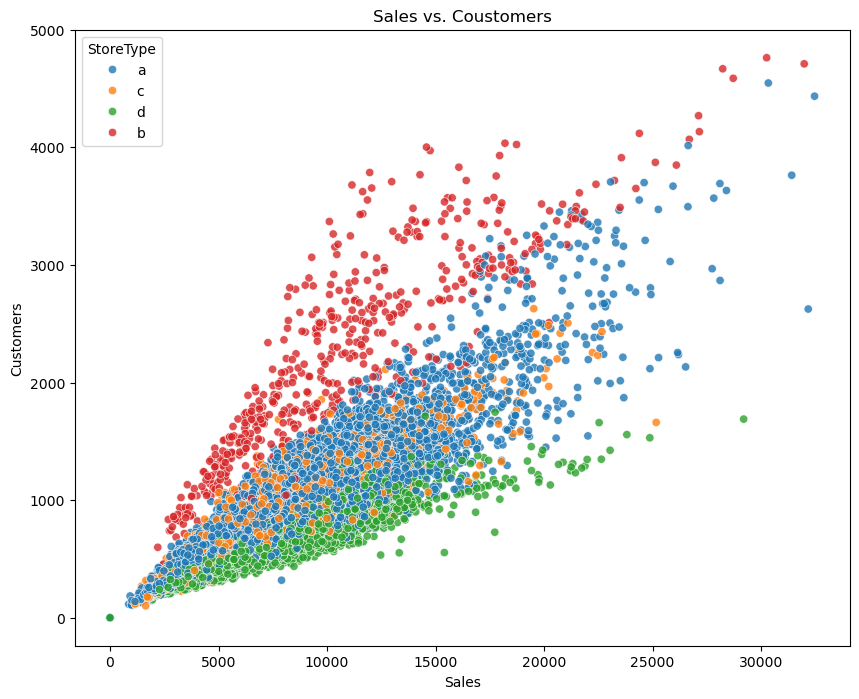

In [34]:
plt.figure(figsize = (10, 8))
temp_df = merged_df.sample(40000)
plt.title('Sales vs. Coustomers')
sns.scatterplot(data = temp_df, x = temp_df.Sales, y = temp_df.Customers, hue = 'StoreType', alpha = 0.8)
plt.show()

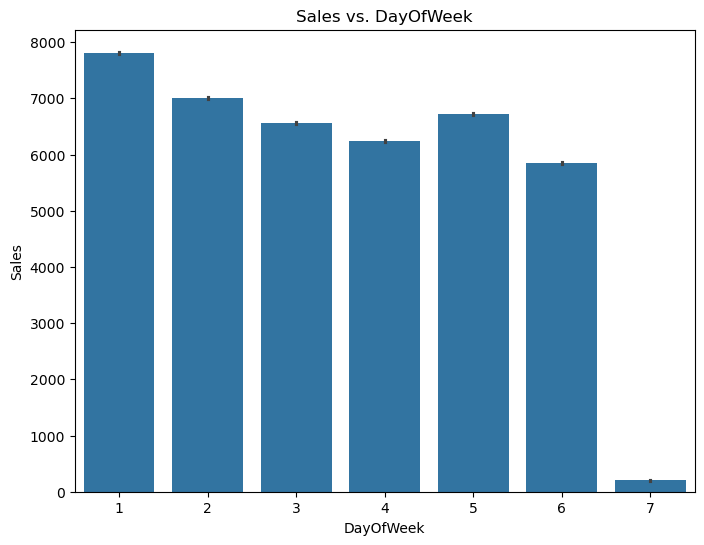

In [35]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'DayOfWeek', y = 'Sales')
plt.show()

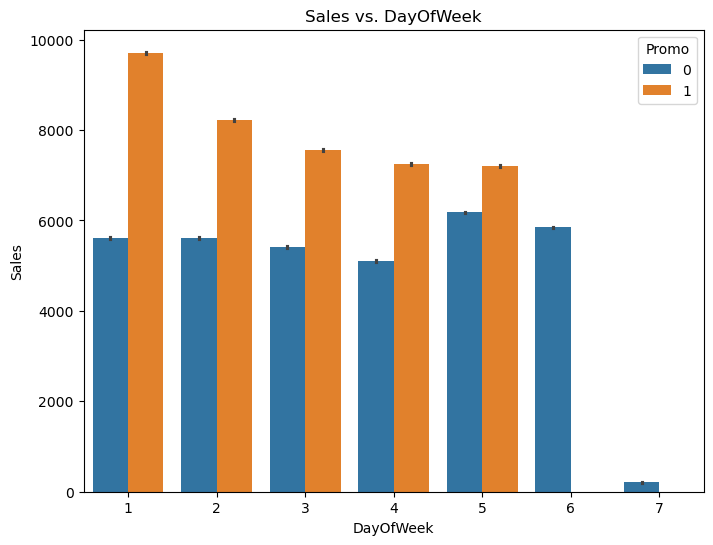

In [37]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'DayOfWeek', y = 'Sales', hue = 'Promo')
plt.show()

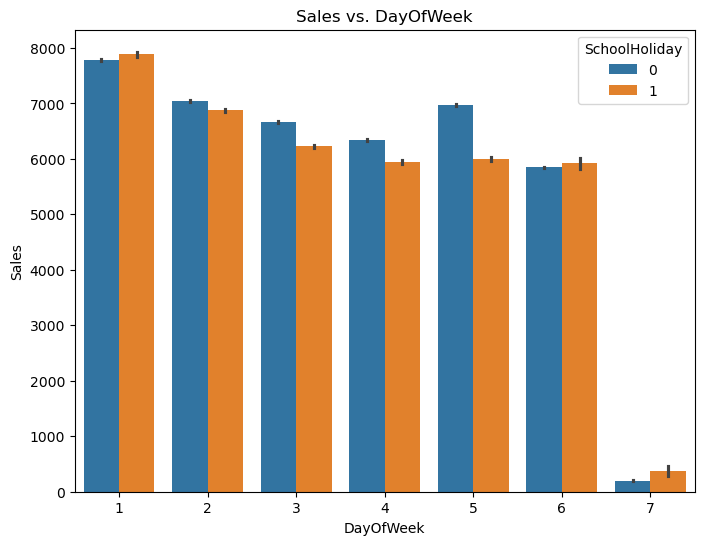

In [38]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'DayOfWeek', y = 'Sales', hue = 'SchoolHoliday')
plt.show()

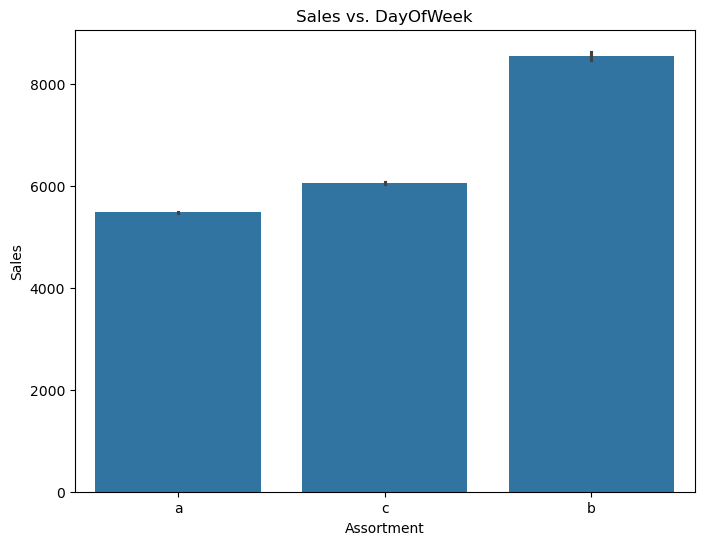

In [40]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'Assortment', y = 'Sales')
plt.show()

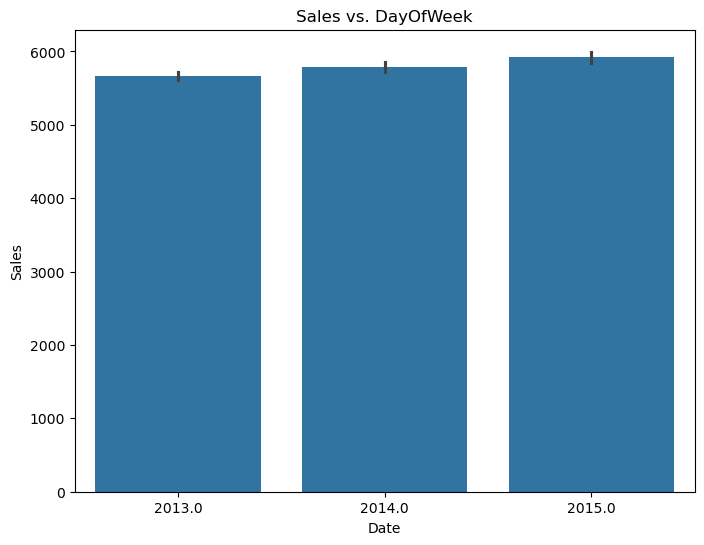

In [41]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.year, y = 'Sales')
plt.show()

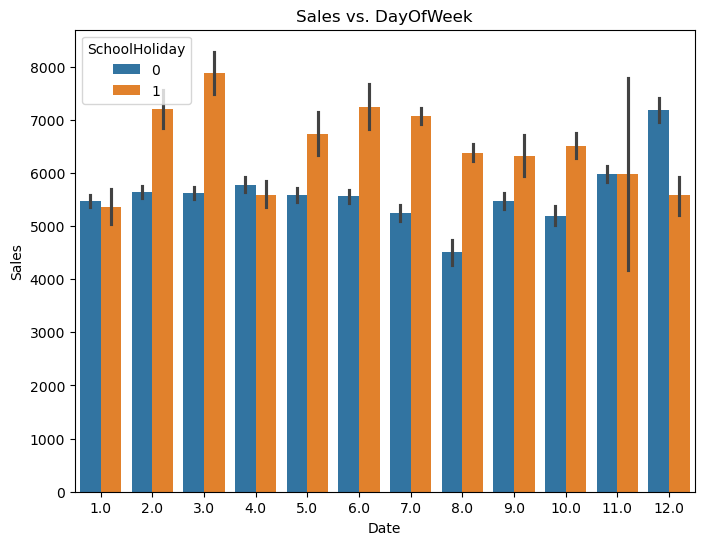

In [42]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.month, y = 'Sales', hue ='SchoolHoliday' )
plt.show()

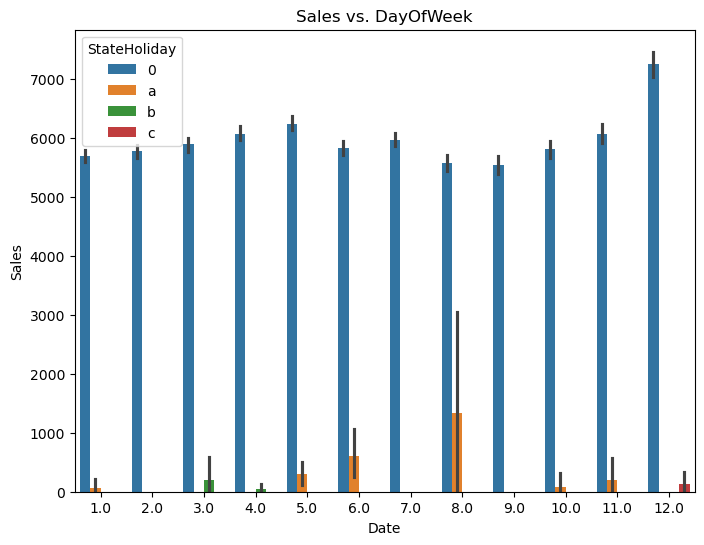

In [43]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.month, y = 'Sales', hue = 'StateHoliday' )
plt.show()

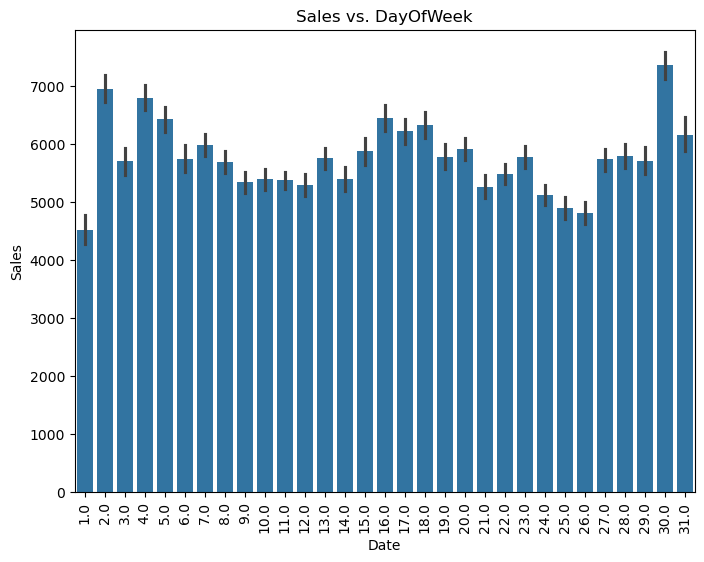

In [44]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.day, y = 'Sales')
plt.xticks(rotation = 90)
plt.show()

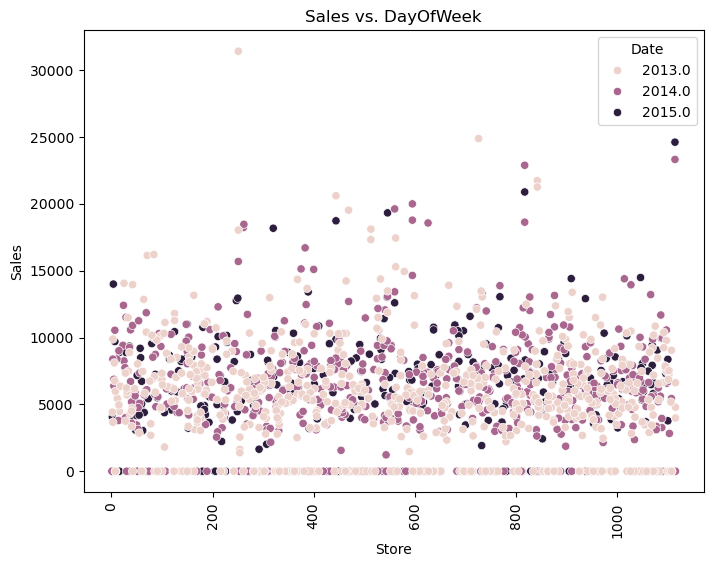

In [45]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.scatterplot(data = merged_df.sample(40000), x = 'Store', y = 'Sales',  hue = pd.to_datetime(temp_df.Date).dt.year)
plt.xticks(rotation = 90)
plt.show()

In [48]:
(pd.to_datetime(merged_df.Date).dt.year).unique

<bound method Series.unique of 0          2015
1          2015
2          2015
3          2015
4          2015
           ... 
1017204    2013
1017205    2013
1017206    2013
1017207    2013
1017208    2013
Name: Date, Length: 1017209, dtype: int32>

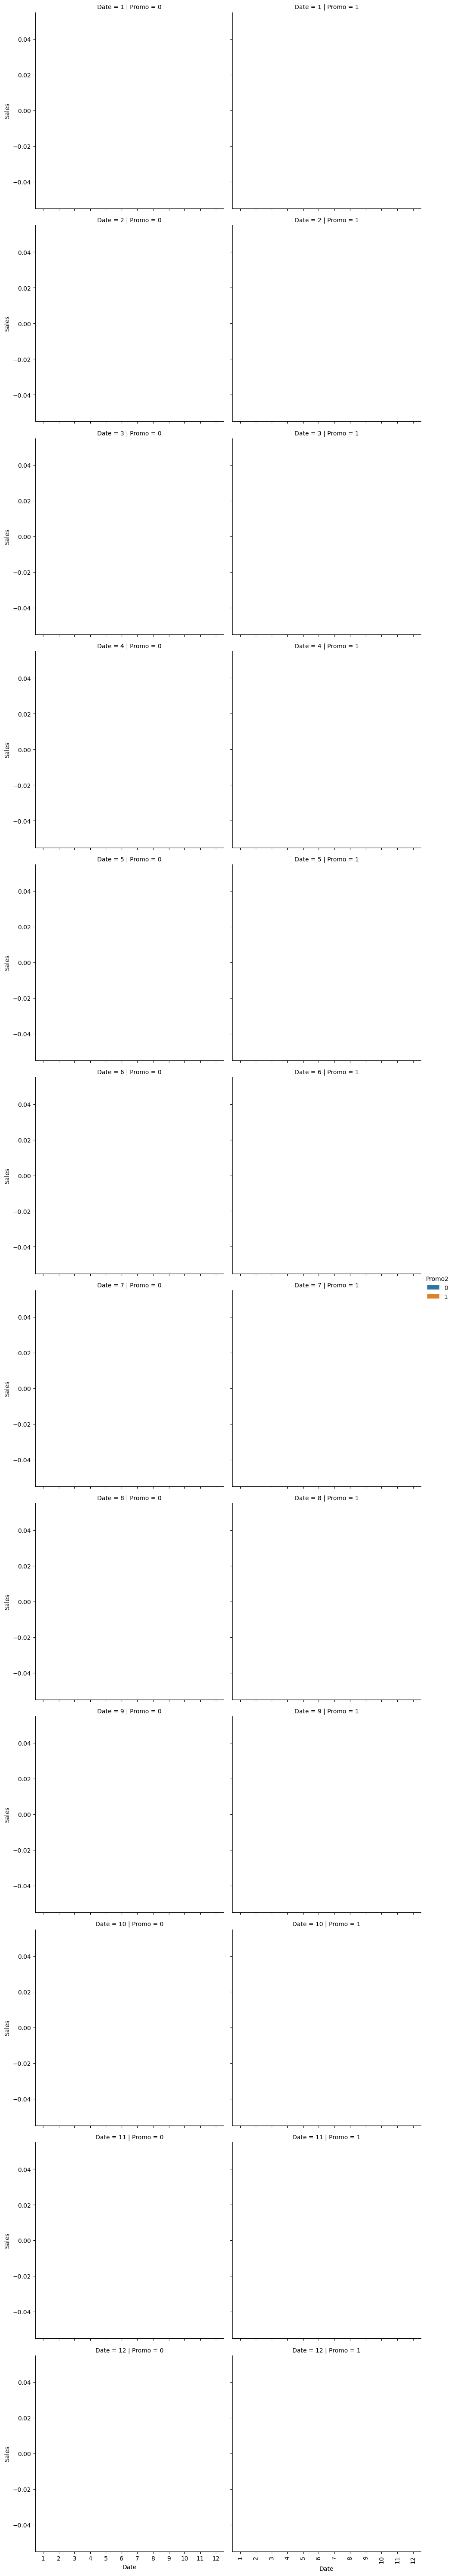

In [49]:
sns.catplot(kind='bar', data = merged_df, x=pd.to_datetime(merged_df.Date).dt.month, y='Sales', row=pd.to_datetime(merged_df.Date).dt.year , col='Promo', hue='Promo2')
plt.xticks(rotation = 90)
plt.show()

In [50]:
numeric_df = merged_df.select_dtypes(include = 'number')
merged_df_corr = numeric_df.corr()
merged_df_corr['Sales'].sort_values(ascending = False)

Sales                        1.000000
Customers                    0.894711
Open                         0.678472
Promo                        0.452345
SchoolHoliday                0.085124
Promo2SinceWeek              0.059558
CompetitionOpenSinceYear     0.012659
Store                        0.005126
CompetitionDistance         -0.019229
Promo2SinceYear             -0.021127
CompetitionOpenSinceMonth   -0.028257
Promo2                      -0.091040
DayOfWeek                   -0.462125
Name: Sales, dtype: float64

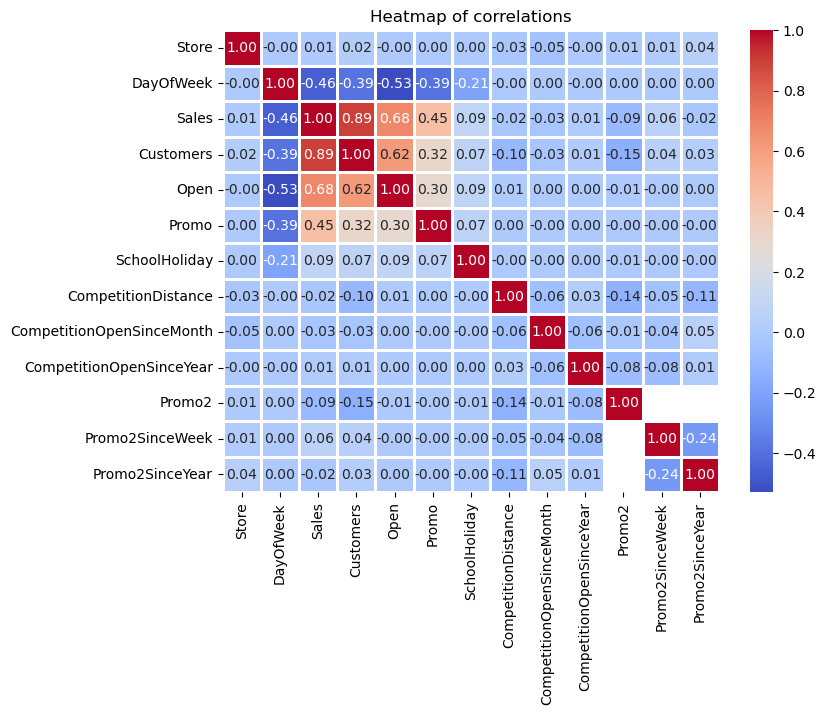

In [51]:
plt.figure(figsize = (8, 6))
plt.title('Heatmap of correlations')
sns.heatmap(data = merged_df_corr, annot = True, cmap = 'coolwarm', linewidths = 0.8, fmt='.2f')
plt.show()

## Preprocessing and Feature Engineering

Let's take a look at the available columns, and figure out if we can create new columns or apply any useful transformations.

لذلك، قد يكون عمود التاريخ مفيد جدًا في:

- تقسيم البيانات زمنياً: حتى لا يحدث تسريب للبيانات من المستقبل إلى الماضي أثناء التدريب والاختبار.  
- استخراج ميزات زمنية: مثل السنة، الشهر، اليوم، اليوم في الأسبوع، موسم السنة، وهكذا، مما قد يساعد النموذج على التعرف على الأنماط الموسمية أو الاتجاهات.  
- فهم تغيرات السوق أو العمليات عبر الزمن: قد تتغير الأنماط مع مرور الزمن، ومن المهم أن يأخذ نموذجك ذلك في الحسبان.

In [55]:
merged_df.info()
#  عامود التاريخ قد لا يفيدني الن جميع بيانات التدريب تنتمي الى التواريخ القديمه والاختبار للجديد

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO


### Date

First, let's convert `Date` to a `datecolumn` and extract different parts of the date.

In [57]:
pd.to_datetime(merged_df['Date']).dt.isocalendar()

,year,week,day
0,2015,31,5
1,2015,31,5
2,2015,31,5
3,2015,31,5
4,2015,31,5
...,...,...,...
1017204,2013,1,2
1017205,2013,1,2
1017206,2013,1,2
1017207,2013,1,2


In [58]:
def split_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['WeekOfYear'] = df.Date.dt.isocalendar().week

In [60]:
split_date(merged_df)
split_date(merged_test_df)

In [79]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1


### Store Open/Closed

Next, notice that the sales are zero whenever the store is closed.

In [82]:
merged_df[merged_df.Open == 0].Sales.value_counts()

Sales
0    172817
Name: count, dtype: int64

In [84]:
merged_df = merged_df[merged_df.Open == 1].copy()

### Competition
Next, we can use the columns `CompetitionOpenSince[Month/Year]` columns from `store_df` to compute the number of months for which a competitor has been open near the store.

بدل من وضع المسافه والسنه والشهر نضع عدد الاشهر التي بقي فيها المتجر مفتوح هذا افضل

In [87]:
merged_df.sample(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
459492,898,5,2014-05-16,5849,714,1,0,0,0,a,a,18540.0,NaN,NaN,0,NaN,NaN,NaN,2014,5,16,20
314335,417,4,2014-10-09,7942,803,1,1,0,1,a,c,840.0,NaN,NaN,1,10.0,2014.0,"Jan,Apr,Jul,Oct",2014,10,9,41
66895,1111,2,2015-06-02,6758,517,1,1,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2015,6,2,23
371830,969,6,2014-08-09,2750,468,1,0,0,0,a,c,600.0,11.0,1999.0,1,10.0,2013.0,"Jan,Apr,Jul,Oct",2014,8,9,32
727382,73,2,2013-09-17,4063,494,1,0,0,0,a,c,1650.0,9.0,2008.0,0,NaN,NaN,NaN,2013,9,17,38
128573,349,2,2015-04-07,9999,995,1,0,0,1,c,c,1490.0,4.0,2009.0,0,NaN,NaN,NaN,2015,4,7,15
648045,1016,4,2013-11-28,5676,495,1,0,0,0,c,c,550.0,NaN,NaN,1,35.0,2010.0,"Mar,Jun,Sept,Dec",2013,11,28,48
466135,851,6,2014-05-10,7018,667,1,0,0,0,d,c,2330.0,NaN,NaN,1,49.0,2014.0,"Mar,Jun,Sept,Dec",2014,5,10,19
483940,816,4,2014-04-24,4098,681,1,0,0,1,c,c,460.0,NaN,NaN,0,NaN,NaN,NaN,2014,4,24,17
719150,761,3,2013-09-25,8926,1019,1,1,0,0,a,a,2390.0,9.0,2012.0,0,NaN,NaN,NaN,2013,9,25,39


In [89]:
def comp_months(df):
    df['CompetitionOpen'] = 12 * (df.Year - df.CompetitionOpenSinceYear) + (df.Month - df.CompetitionOpenSinceMonth)
    df['CompetitionOpen'] = df['CompetitionOpen'].map(lambda x: 0 if x < 0 else x).fillna(0)

In [91]:
comp_months(merged_df)
comp_months(merged_test_df)

In [92]:
merged_df[['Date', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpen']].sample(10)

,Date,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpen
569381,2014-02-06,5830.0,2011.0,9.0,29.0
316217,2014-10-07,910.0,NaN,NaN,0.0
973331,2013-02-09,50.0,NaN,NaN,0.0
883557,2013-04-30,2090.0,2008.0,12.0,52.0
712445,2013-10-01,4330.0,2011.0,2.0,32.0
743060,2013-09-03,1540.0,NaN,NaN,0.0
989610,2013-01-25,2960.0,2014.0,10.0,0.0
837704,2013-06-10,3160.0,2009.0,9.0,45.0
125308,2015-04-10,16350.0,2005.0,7.0,117.0
946614,2013-03-05,25430.0,1999.0,5.0,166.0


### Additional Promotion

We can also add some additional columns to indicate how long a store has been running `Promo2` and whether a new round of `Promo2` starts in the current month.

In [96]:
def check_promo_month(row):
    month2str = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',              
                 7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}
    try:
        months = (row['PromoInterval'] or '').split(',')
        if row['Promo2Open'] and month2str[row['Month']] in months:
            return 1
        else:
            return 0
    except Exception:
        return 0

def promo_cols(df):
    # Months since Promo2 was open
    df['Promo2Open'] = 12 * (df.Year - df.Promo2SinceYear) +  (df.WeekOfYear - df.Promo2SinceWeek)*7/30.5
    df['Promo2Open'] = df['Promo2Open'].map(lambda x: 0 if x < 0 else x).fillna(0) * df['Promo2']
    # Whether a new round of promotions was started in the current month
    df['IsPromo2Month'] = df.apply(check_promo_month, axis=1) * df['Promo2']

In [98]:
promo_cols(merged_df)
promo_cols(merged_test_df)

In [99]:
merged_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval', 'Promo2Open', 'IsPromo2Month']].sample(20)

,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Promo2Open,IsPromo2Month
543348,2014-03-01,1,2011.0,40.0,"Jan,Apr,Jul,Oct",28.885246,0
781533,2013-07-31,0,NaN,NaN,NaN,0.000000,0
732635,2013-09-13,1,2013.0,5.0,"Feb,May,Aug,Nov",7.344262,0
937392,2013-03-13,0,NaN,NaN,NaN,0.000000,0
384254,2014-07-26,0,NaN,NaN,NaN,0.000000,0
33710,2015-07-01,1,2009.0,39.0,"Jan,Apr,Jul,Oct",69.245902,1
539981,2014-03-05,1,2010.0,13.0,"Jan,Apr,Jul,Oct",47.311475,0
665402,2013-11-12,0,NaN,NaN,NaN,0.000000,0
105458,2015-04-28,0,NaN,NaN,NaN,0.000000,0
763660,2013-08-16,1,2010.0,39.0,"Jan,Apr,Jul,Oct",34.622951,0


The features related to competition and promotion are now much more useful.

In [101]:
numeric_df = merged_df.select_dtypes(include = 'number')
merged_df_corr = numeric_df.corr()
merged_df_corr['Sales'].sort_values(ascending = False)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Promo2SinceWeek              0.095311
WeekOfYear                   0.074472
Month                        0.073600
SchoolHoliday                0.038617
Year                         0.036169
CompetitionOpenSinceYear     0.016101
Store                        0.007710
CompetitionOpen             -0.003196
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Day                         -0.051849
Promo2Open                  -0.060761
IsPromo2Month               -0.065369
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

### Input and Target Columns

Let's select the columns that we'll use for training.

In [103]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month'],
      dtype='object')

In [104]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
             'StoreType', 'Assortment', 'Promo2', 'Year', 'Month', 'Day', 'CompetitionDistance',
             'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month']
target_cols = 'Sales'

# اذا اردنا انشاء توقعات لمتجر غير موجود بالبيانات فلا يجب وضع عامود المتجر

In [105]:
inputs = merged_df[input_cols].copy()
targets = merged_df[target_cols].copy()
test_inputs = merged_test_df[input_cols].copy()

Let's also identify numeric and categorical columns. Note that we can treat binary categorical columns (0/1) as numeric columns.

In [107]:
numeric_cols = ['Store', 'Promo', 'SchoolHoliday', 
              'CompetitionDistance', 'CompetitionOpen', 'Promo2', 'Promo2Open', 'IsPromo2Month',
              'Day', 'Month', 'Year', 'WeekOfYear',  ]
categorical_cols = ['DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment']

### Impute missing numerical data

In [109]:
inputs[numeric_cols].isna().sum()
#  قد يكون لا يوجد متاجر منافسه بجوارنا واذا وضعنا صفر قد يدل على العكس ان المتجر بجوارنا

Store                     0
Promo                     0
SchoolHoliday             0
CompetitionDistance    2186
CompetitionOpen           0
Promo2                    0
Promo2Open                0
IsPromo2Month             0
Day                       0
Month                     0
Year                      0
WeekOfYear                0
dtype: int64

In [110]:
test_inputs[numeric_cols].isna().sum()

Store                   0
Promo                   0
SchoolHoliday           0
CompetitionDistance    96
CompetitionOpen         0
Promo2                  0
Promo2Open              0
IsPromo2Month           0
Day                     0
Month                   0
Year                    0
WeekOfYear              0
dtype: int64

Seems like competition distance is the only missing value, and we can simply fill it with the highest value (to indicate that competition is very far away).

In [112]:
max_distance = inputs['CompetitionDistance'].max()
max_distance

75860.0

In [113]:
inputs['CompetitionDistance'] = inputs['CompetitionDistance'].fillna(max_distance*2)
test_inputs['CompetitionDistance'] = test_inputs['CompetitionDistance'].fillna(max_distance*2)

### Scale Numeric Values

Let's scale numeric values to the 0 to 1 range.

In [115]:
inputs.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,844392.0,558.42292,321.731914,1.0,280.0,558.0,837.0,1115.0
DayOfWeek,844392.0,3.520361,1.723689,1.0,2.0,3.0,5.0,7.0
Promo,844392.0,0.446352,0.497114,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,844392.0,0.19358,0.395103,0.0,0.0,0.0,0.0,1.0
Promo2,844392.0,0.498684,0.499999,0.0,0.0,0.0,1.0,1.0
Year,844392.0,2013.831937,0.77726,2013.0,2013.0,2014.0,2014.0,2015.0
Month,844392.0,5.845738,3.323931,1.0,3.0,6.0,8.0,12.0
Day,844392.0,15.835683,8.683456,1.0,8.0,16.0,23.0,31.0
CompetitionDistance,844392.0,5836.629326,10773.494513,20.0,710.0,2330.0,6910.0,151720.0
WeekOfYear,844392.0,23.646801,14.389785,1.0,11.0,23.0,35.0,52.0


In [116]:
from sklearn.preprocessing import MinMaxScaler

In [117]:
scaler = MinMaxScaler().fit(inputs[numeric_cols])

In [118]:
inputs[numeric_cols] = scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

### Encode Categorical Columns

<img src="https://i.imgur.com/n8GuiOO.png" width="640">

Let's one-hot encode categorical columns.

In [120]:
from sklearn.preprocessing import OneHotEncoder

In [121]:
inputs[categorical_cols].isnull().sum()

DayOfWeek       0
StateHoliday    0
StoreType       0
Assortment      0
dtype: int64

In [122]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
encoded_cols

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

In [123]:
inputs[encoded_cols] = encoder.transform(inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [124]:
X = inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

We haven't created a validation set yet, because we'll use K-fold cross validation.

> **EXERCISE**: Look through the notebooks created by participants in the Kaggle competition and apply some other ideas for feature engineering. https://www.kaggle.com/c/rossmann-store-sales/code?competitionId=4594&sortBy=voteCount

## Gradient Boosting

We're now ready to train our gradient boosting machine (GBM) model. Here's how a GBM model works:

1. The average value of the target column and uses as an initial prediction every input.
2. The residuals (difference) of the predictions with the targets are computed.
3. A decision tree of limited depth is trained to **predict just the residuals** for each input.
4. Predictions from the decision tree are scaled using a parameter called the learning rate (this prevents overfitting)
5. Scaled predictions fro the tree are added to the previous predictions to obtain the new and improved predictions.
6. Steps 2 to 5 are repeated to create new decision trees, each of which is trained to predict just the residuals from the previous prediction.

The term "gradient" refers to the fact that each decision tree is trained with the purpose of reducing the loss from the previous iteration (similar to gradient descent). The term "boosting" refers the general technique of training new models to improve the results of an existing model. 

> **EXERCISE**: Can you describe in your own words how a gradient boosting machine is different from a random forest?


For a mathematical explanation of gradient boosting, check out the following resources:

- [XGBoost Documentation](https://xgboost.readthedocs.io/en/latest/tutorials/model.html)
- [Video Tutorials on StatQuest](https://www.youtube.com/watch?v=3CC4N4z3GJc&list=PLblh5JKOoLUJjeXUvUE0maghNuY2_5fY6)

Here's a visual representation of gradient boosting:

![](https://miro.medium.com/max/560/1*85QHtH-49U7ozPpmA5cAaw.png)


### Training

To train a GBM, we can use the `XGBRegressor` class from the [`XGBoost`](https://xgboost.readthedocs.io/en/latest/) library.

In [131]:
from xgboost import XGBRegressor, plot_tree

In [135]:
from sklearn.ensemble import GradientBoostingRegressor

In [142]:
#  learning_rate   يستخدم لمنع الافراط في التعلم
XGBRegressor?

Init signature:
XGBRegressor(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'reg:squarederror',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost regression.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : typing.Optional[int]
        Number of gradient boosted trees.  Equivalent to number of boosting
        rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with hig

In [143]:
model = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=20, max_depth=4)

In [147]:
GradientBoostingRegressor?

Init signature:
GradientBoostingRegressor(
    *,
    loss='squared_error',
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    criterion='friedman_mse',
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_depth=3,
    min_impurity_decrease=0.0,
    init=None,
    random_state=None,
    max_features=None,
    alpha=0.9,
    verbose=0,
    max_leaf_nodes=None,
    warm_start=False,
    validation_fraction=0.1,
    n_iter_no_change=None,
    tol=0.0001,
    ccp_alpha=0.0,
)
Docstring:     
Gradient Boosting for regression.

This estimator builds an additive model in a forward stage-wise fashion; it
allows for the optimization of arbitrary differentiable loss functions. In
each stage a regression tree is fit on the negative gradient of the given
loss function.

:class:`sklearn.ensemble.HistGradientBoostingRegressor` is a much faster
variant of this algorithm for intermediate datasets (`n_samples >= 10_000`).

Read more in the :ref:`Us

In [152]:
model2 = GradientBoostingRegressor(random_state=42, n_estimators=20, max_depth=4)

In [153]:
%%time
model2.fit(X, targets)

CPU times: total: 31.6 s
Wall time: 31.7 s


GradientBoostingRegressor(max_depth=4, n_estimators=20, random_state=42)

In [154]:
%%time
model.fit(X, targets)

CPU times: total: 7.05 s
Wall time: 1.02 s


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=-1, num_parallel_tree=None, ...)

> **EXERCISE**: Explain how the `.fit` method of `XGBRegressor` applies the iterative machine learning workflow to train the model using the training data.
> 
> <img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">

### Prediction

We can now make predictions and evaluate the model using `model.predict`.

In [164]:
preds = model.predict(X)
preds2 = model2.predict(X)

In [166]:
print(preds)
print(targets)
print(preds2)

[ 8073.2007  7278.4395  8812.854  ...  7913.415   7336.718  10780.133 ]
0           5263
1           6064
2           8314
3          13995
4           4822
           ...  
1016776     3375
1016827    10765
1016863     5035
1017042     4491
1017190     5961
Name: Sales, Length: 844392, dtype: int64
[8115.80259741 7736.12642746 8271.75137377 ... 7544.39035347 7186.76604835
 8619.26844615]


### Evaluation

Let's evaluate the predictions using RMSE error.

In [168]:
from sklearn.metrics import root_mean_squared_error

In [169]:
root_mean_squared_error(targets, preds)

2357.1278101525777

In [170]:
root_mean_squared_error(targets, preds2)

2596.330622616426

In [171]:
model100 = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=1000, max_depth=4)
model100.fit(X, targets)
preds100 = model100.predict(X)
root_mean_squared_error(targets, preds100)

942.463555478927

In [172]:
model100 = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=1000, max_depth=4)
model100.fit(X, targets)
preds100 = model100.predict(X)
root_mean_squared_error(targets, preds100)

942.463555478927

(array([5.550e+02, 4.742e+03, 3.314e+03, 9.590e+02, 2.900e+02, 9.900e+01,
        2.800e+01, 7.000e+00, 5.000e+00, 1.000e+00]),
 array([    0. ,  3260.5,  6521. ,  9781.5, 13042. , 16302.5, 19563. ,
        22823.5, 26084. , 29344.5, 32605. ]),
 <BarContainer object of 10 artists>)

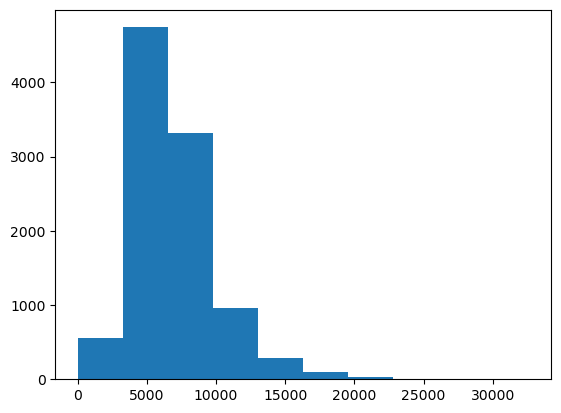

In [173]:
plt.hist(merged_df.Sales.sample(10000))

### Visualization

We can visualize individual trees using `plot_tree` (note: this requires the `graphviz` library to be installed).

In [175]:
from matplotlib.pyplot import rcParams
%matplotlib inline

rcParams['figure.figsize'] = 30,30

In [176]:
!pip install xgboost

In [177]:
!pip install graphviz

In [178]:
!pip install lightgbm

<Axes: >

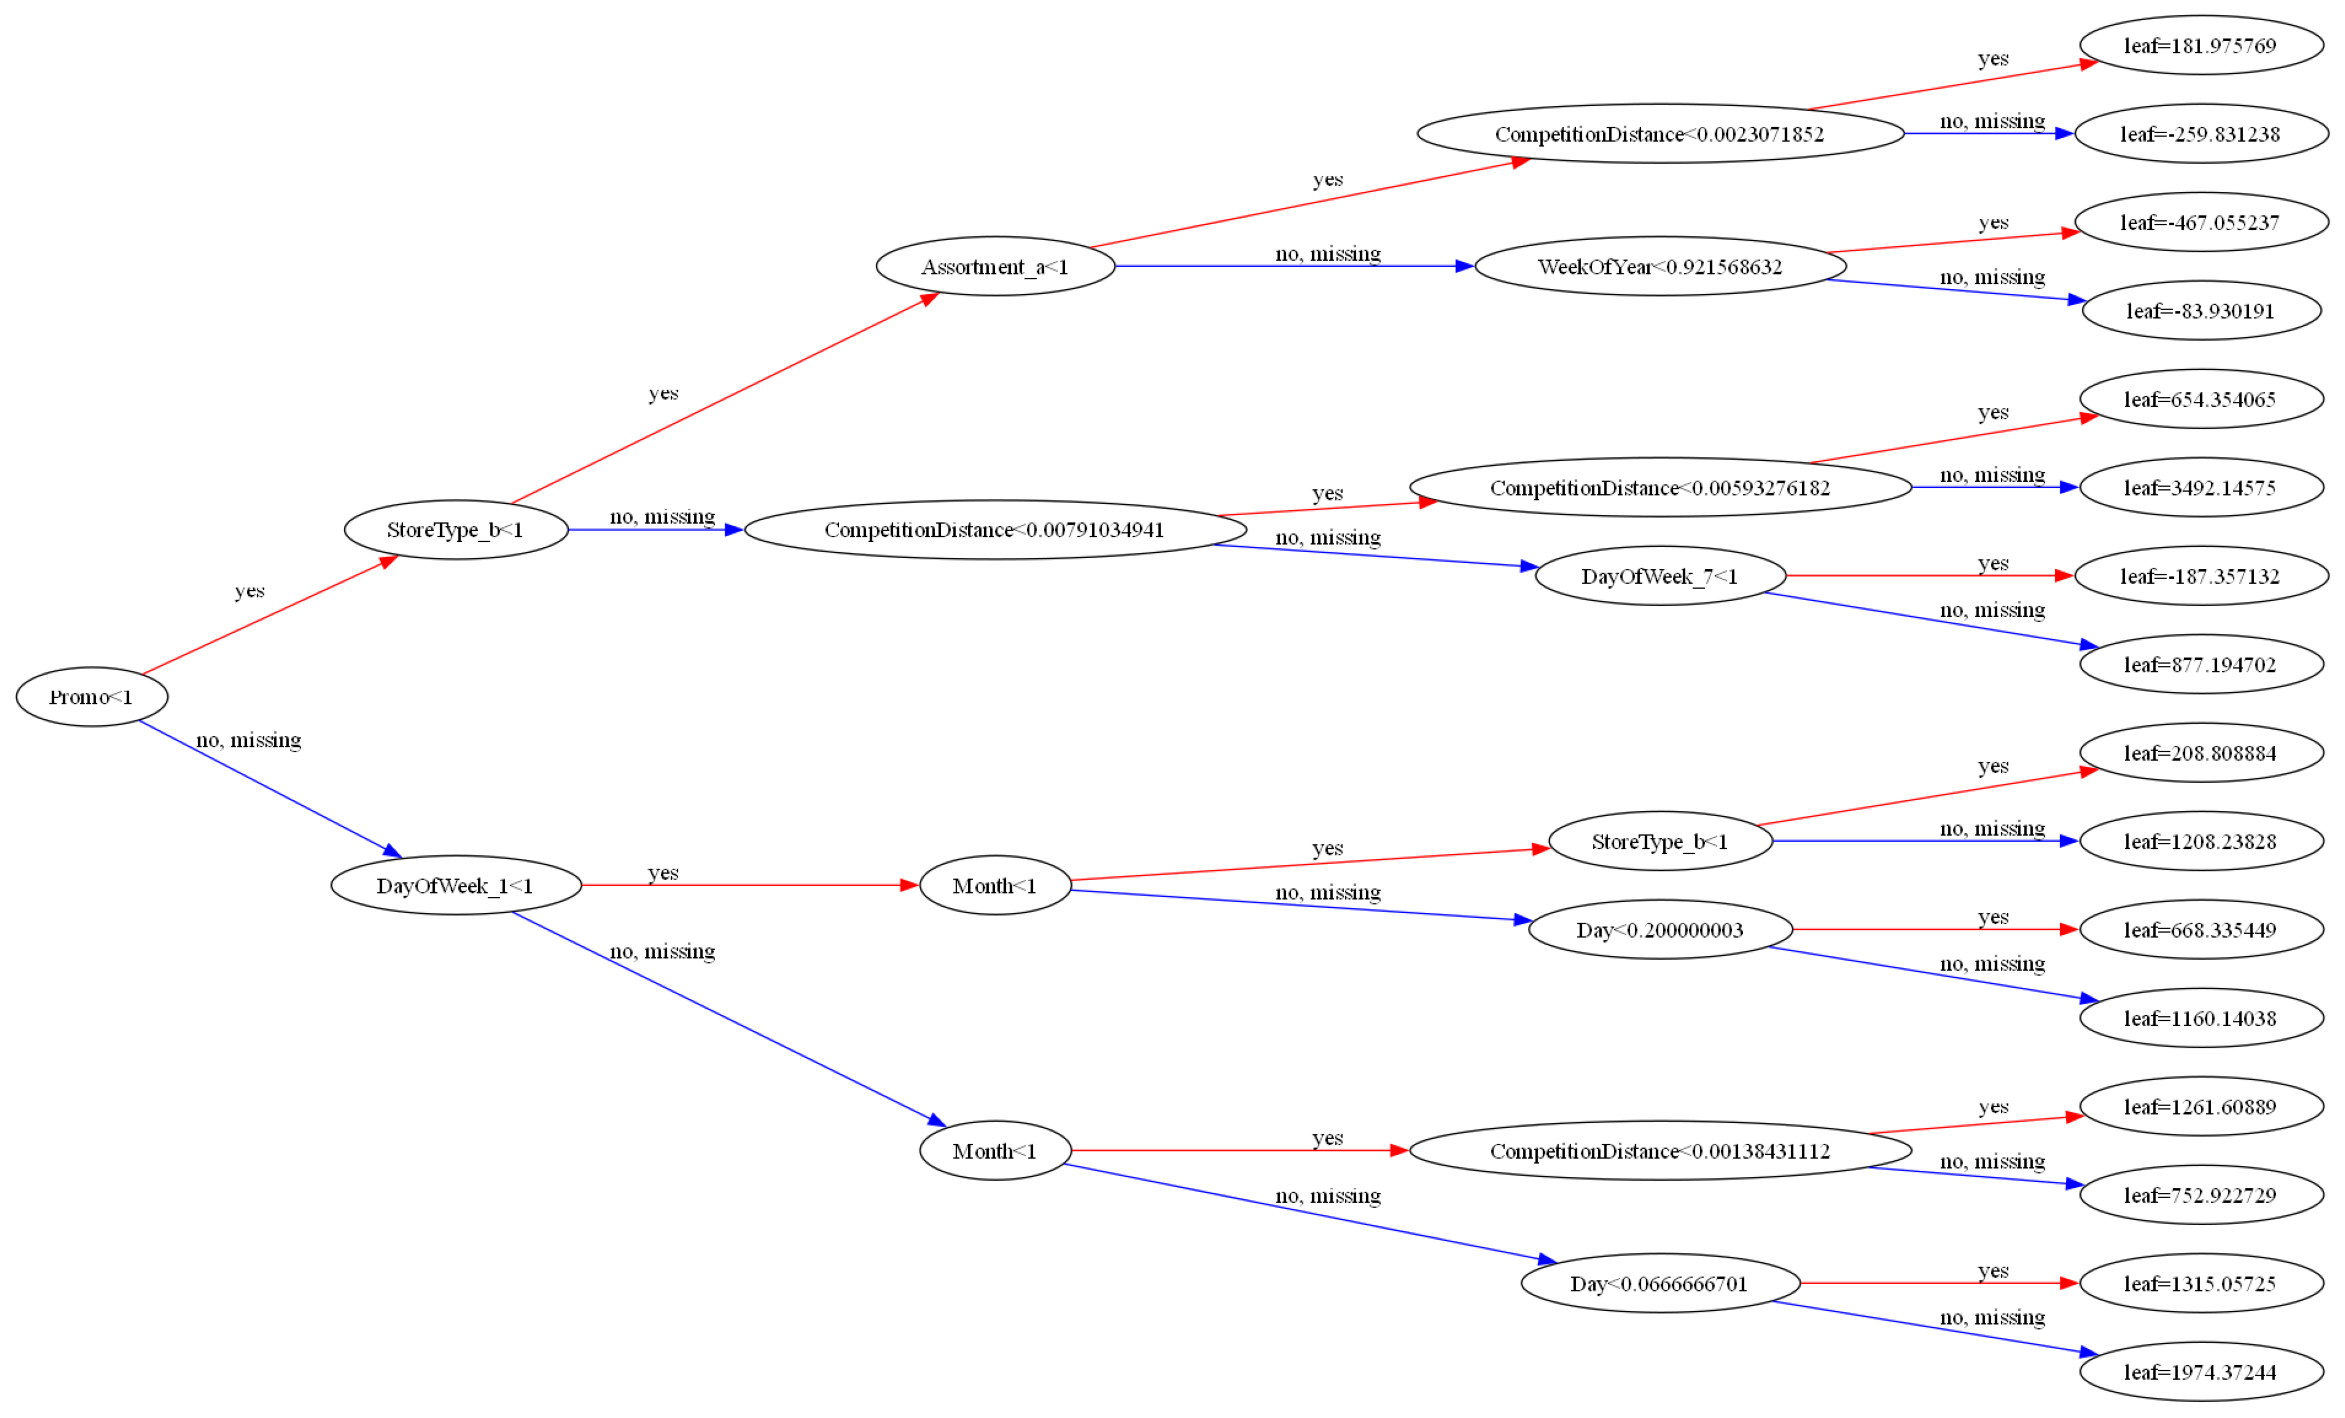

In [179]:
plot_tree(model, rankdir = 'LR', tree_idx = 0)
# rankdir تعني "اتجاه الترتيب" للعقد في الرسم البياني.
# 'LR' تعني "Left to Right" أي عرض الرسم بشكل أفقي من اليسار إلى اليمين.
#  في الورق هذه ليست التوقعات انما النحراف عن المتوسط الذي نتوقعه

<Axes: >

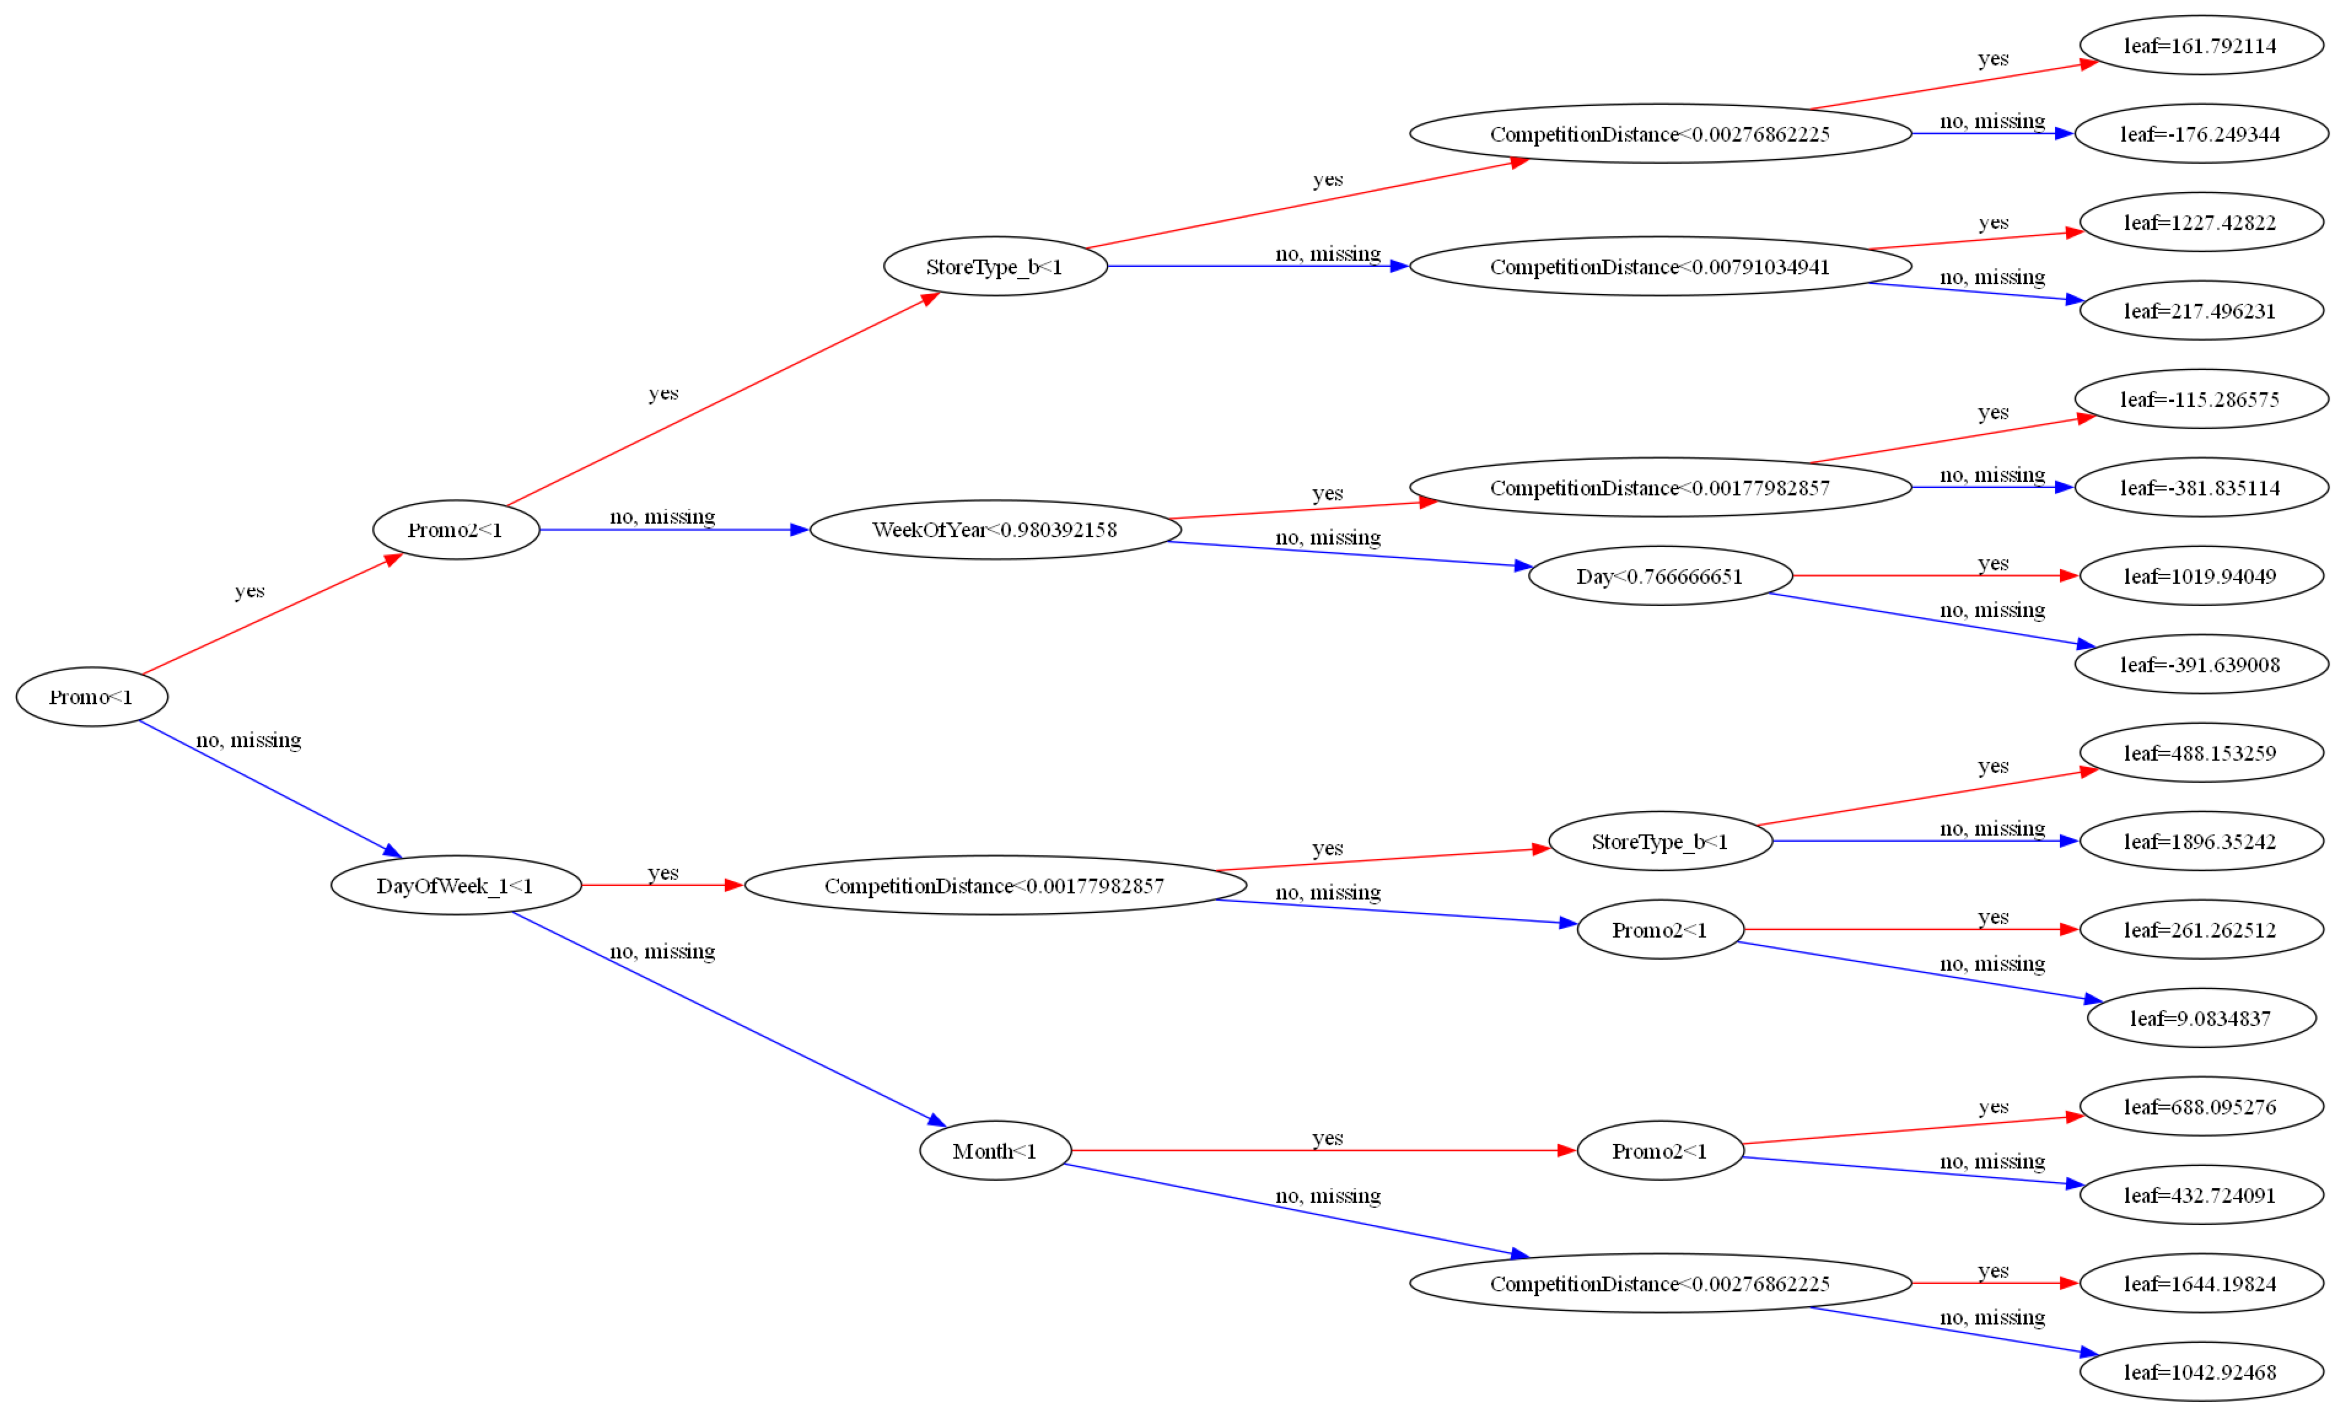

In [180]:
plot_tree(model, rankdir = 'LR', tree_idx = 1)

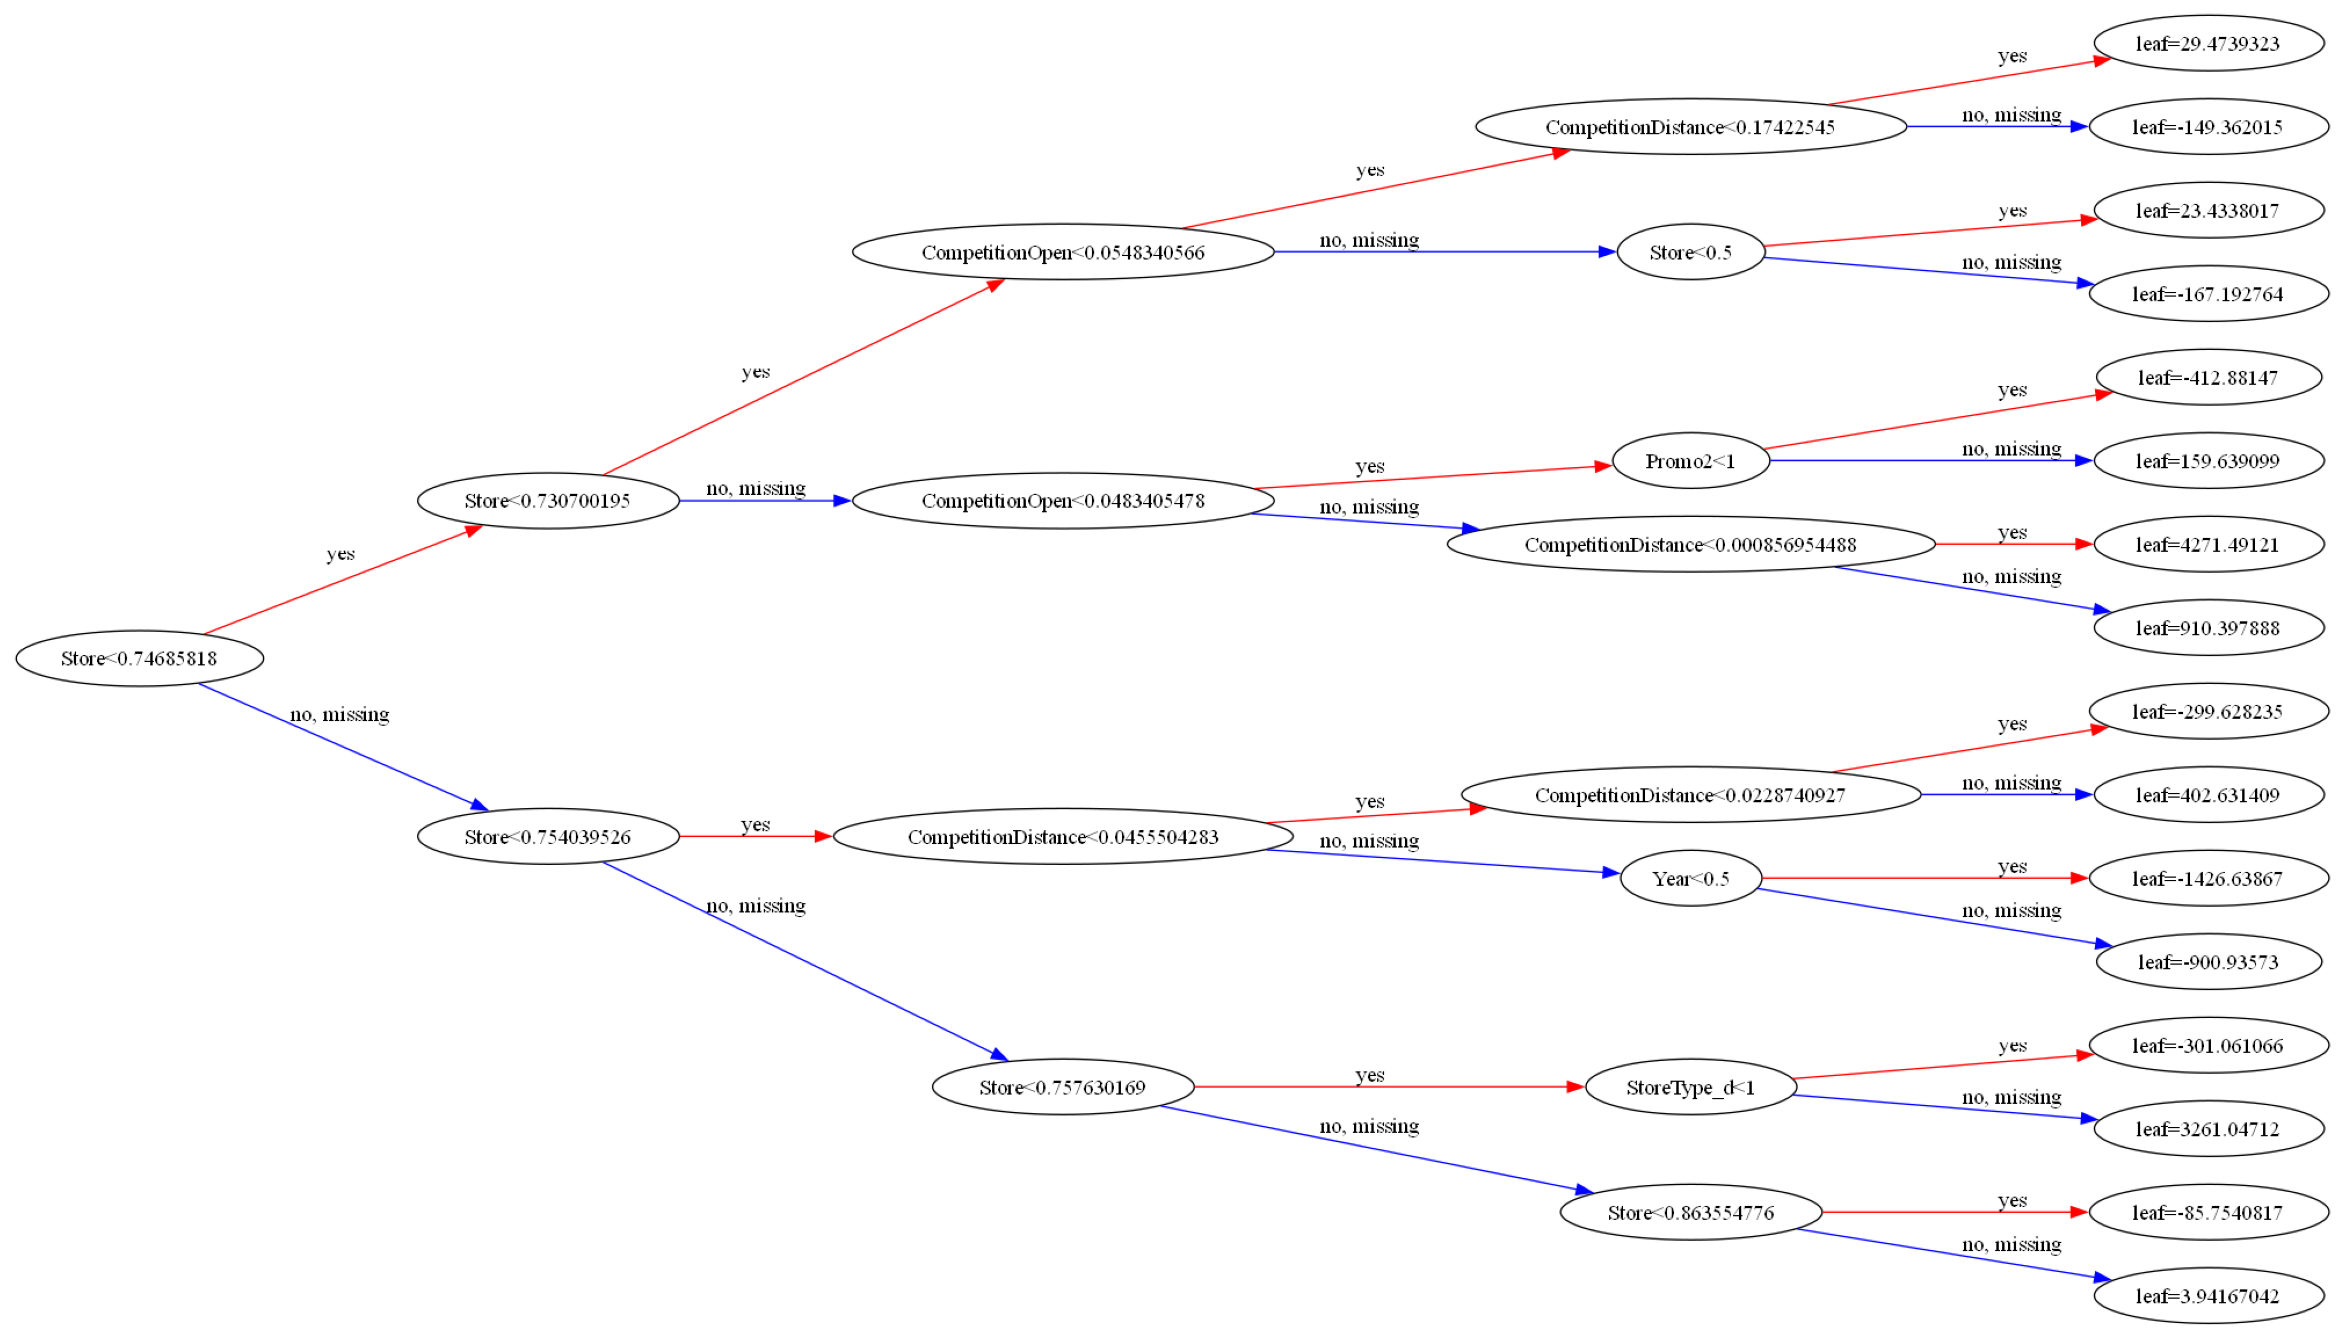

In [181]:
plot_tree(model, rankdir='LR', tree_idx =19);

Notice how the trees only compute residuals, and not the actual target value. We can also visualize the tree as text.

In [183]:
trees = model.get_booster().get_dump()
trees

['0:[Promo<1] yes=1,no=2,missing=2\n\t1:[StoreType_b<1] yes=3,no=4,missing=4\n\t\t3:[Assortment_a<1] yes=7,no=8,missing=8\n\t\t\t7:[CompetitionDistance<0.0023071852] yes=15,no=16,missing=16\n\t\t\t\t15:leaf=181.975769\n\t\t\t\t16:leaf=-259.831238\n\t\t\t8:[WeekOfYear<0.921568632] yes=17,no=18,missing=18\n\t\t\t\t17:leaf=-467.055237\n\t\t\t\t18:leaf=-83.930191\n\t\t4:[CompetitionDistance<0.00791034941] yes=9,no=10,missing=10\n\t\t\t9:[CompetitionDistance<0.00593276182] yes=19,no=20,missing=20\n\t\t\t\t19:leaf=654.354065\n\t\t\t\t20:leaf=3492.14575\n\t\t\t10:[DayOfWeek_7<1] yes=21,no=22,missing=22\n\t\t\t\t21:leaf=-187.357132\n\t\t\t\t22:leaf=877.194702\n\t2:[DayOfWeek_1<1] yes=5,no=6,missing=6\n\t\t5:[Month<1] yes=11,no=12,missing=12\n\t\t\t11:[StoreType_b<1] yes=23,no=24,missing=24\n\t\t\t\t23:leaf=208.808884\n\t\t\t\t24:leaf=1208.23828\n\t\t\t12:[Day<0.200000003] yes=25,no=26,missing=26\n\t\t\t\t25:leaf=668.335449\n\t\t\t\t26:leaf=1160.14038\n\t\t6:[Month<1] yes=13,no=14,missing=14\n\

In [184]:
len(trees)

20

In [185]:
print(trees[0])

0:[Promo<1] yes=1,no=2,missing=2
	1:[StoreType_b<1] yes=3,no=4,missing=4
		3:[Assortment_a<1] yes=7,no=8,missing=8
			7:[CompetitionDistance<0.0023071852] yes=15,no=16,missing=16
				15:leaf=181.975769
				16:leaf=-259.831238
			8:[WeekOfYear<0.921568632] yes=17,no=18,missing=18
				17:leaf=-467.055237
				18:leaf=-83.930191
		4:[CompetitionDistance<0.00791034941] yes=9,no=10,missing=10
			9:[CompetitionDistance<0.00593276182] yes=19,no=20,missing=20
				19:leaf=654.354065
				20:leaf=3492.14575
			10:[DayOfWeek_7<1] yes=21,no=22,missing=22
				21:leaf=-187.357132
				22:leaf=877.194702
	2:[DayOfWeek_1<1] yes=5,no=6,missing=6
		5:[Month<1] yes=11,no=12,missing=12
			11:[StoreType_b<1] yes=23,no=24,missing=24
				23:leaf=208.808884
				24:leaf=1208.23828
			12:[Day<0.200000003] yes=25,no=26,missing=26
				25:leaf=668.335449
				26:leaf=1160.14038
		6:[Month<1] yes=13,no=14,missing=14
			13:[CompetitionDistance<0.00138431112] yes=27,no=28,missing=28
				27:leaf=1261.60889
				28:leaf=752

### Feature importance

Just like decision trees and random forests, XGBoost also provides a feature importance score for each column in the input.

- لحساب اهميه الميزه نستخدم طريقتين وهما
1. Gain: متوسط تحسن الدقة الناتج عن تقسيم العقد باستخدام هذه الميزة.
2. Weight: عدد المرات التي استخدمت فيها الميزة في عقد الأشجار.
3. Cover: المتوسط الإجمالي لعدد العينات التي تأثرت بتقسيم الميزة.

In [187]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [188]:
importance_df.head(10)

,feature,importance
1,Promo,0.309244
12,DayOfWeek_1,0.076455
26,StoreType_d,0.071732
24,StoreType_b,0.066487
5,Promo2,0.040490
3,CompetitionDistance,0.039816
27,Assortment_a,0.038316
25,StoreType_c,0.036829
4,CompetitionOpen,0.034157
9,Month,0.026813


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

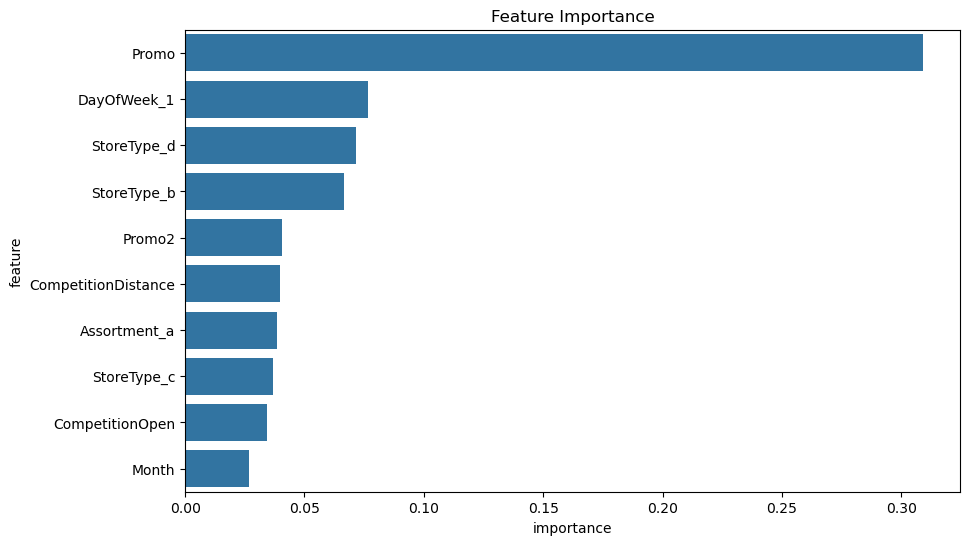

In [189]:
plt.figure(figsize=(10,6))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
#  حسب الميزات نختارها ومن ثصم ندرب المودل ونتحقق هل نحصل على دقه افضل

In [190]:
X.columns

Index(['Store', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpen', 'Promo2', 'Promo2Open', 'IsPromo2Month', 'Day',
       'Month', 'Year', 'WeekOfYear', 'DayOfWeek_1', 'DayOfWeek_2',
       'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6',
       'DayOfWeek_7', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c'],
      dtype='object')

In [191]:
z =['Promo','DayOfWeek_1','StoreType_d','StoreType_b','Promo2','CompetitionDistance',
    'Assortment_a','StoreType_c','CompetitionOpen','Month']

In [192]:
model_newcols = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=1000, max_depth=4)
model_newcols.fit(X[z], targets)
preds_newcols = model_newcols.predict(X[z])
root_mean_squared_error(targets, preds_newcols)

1466.9912139610065

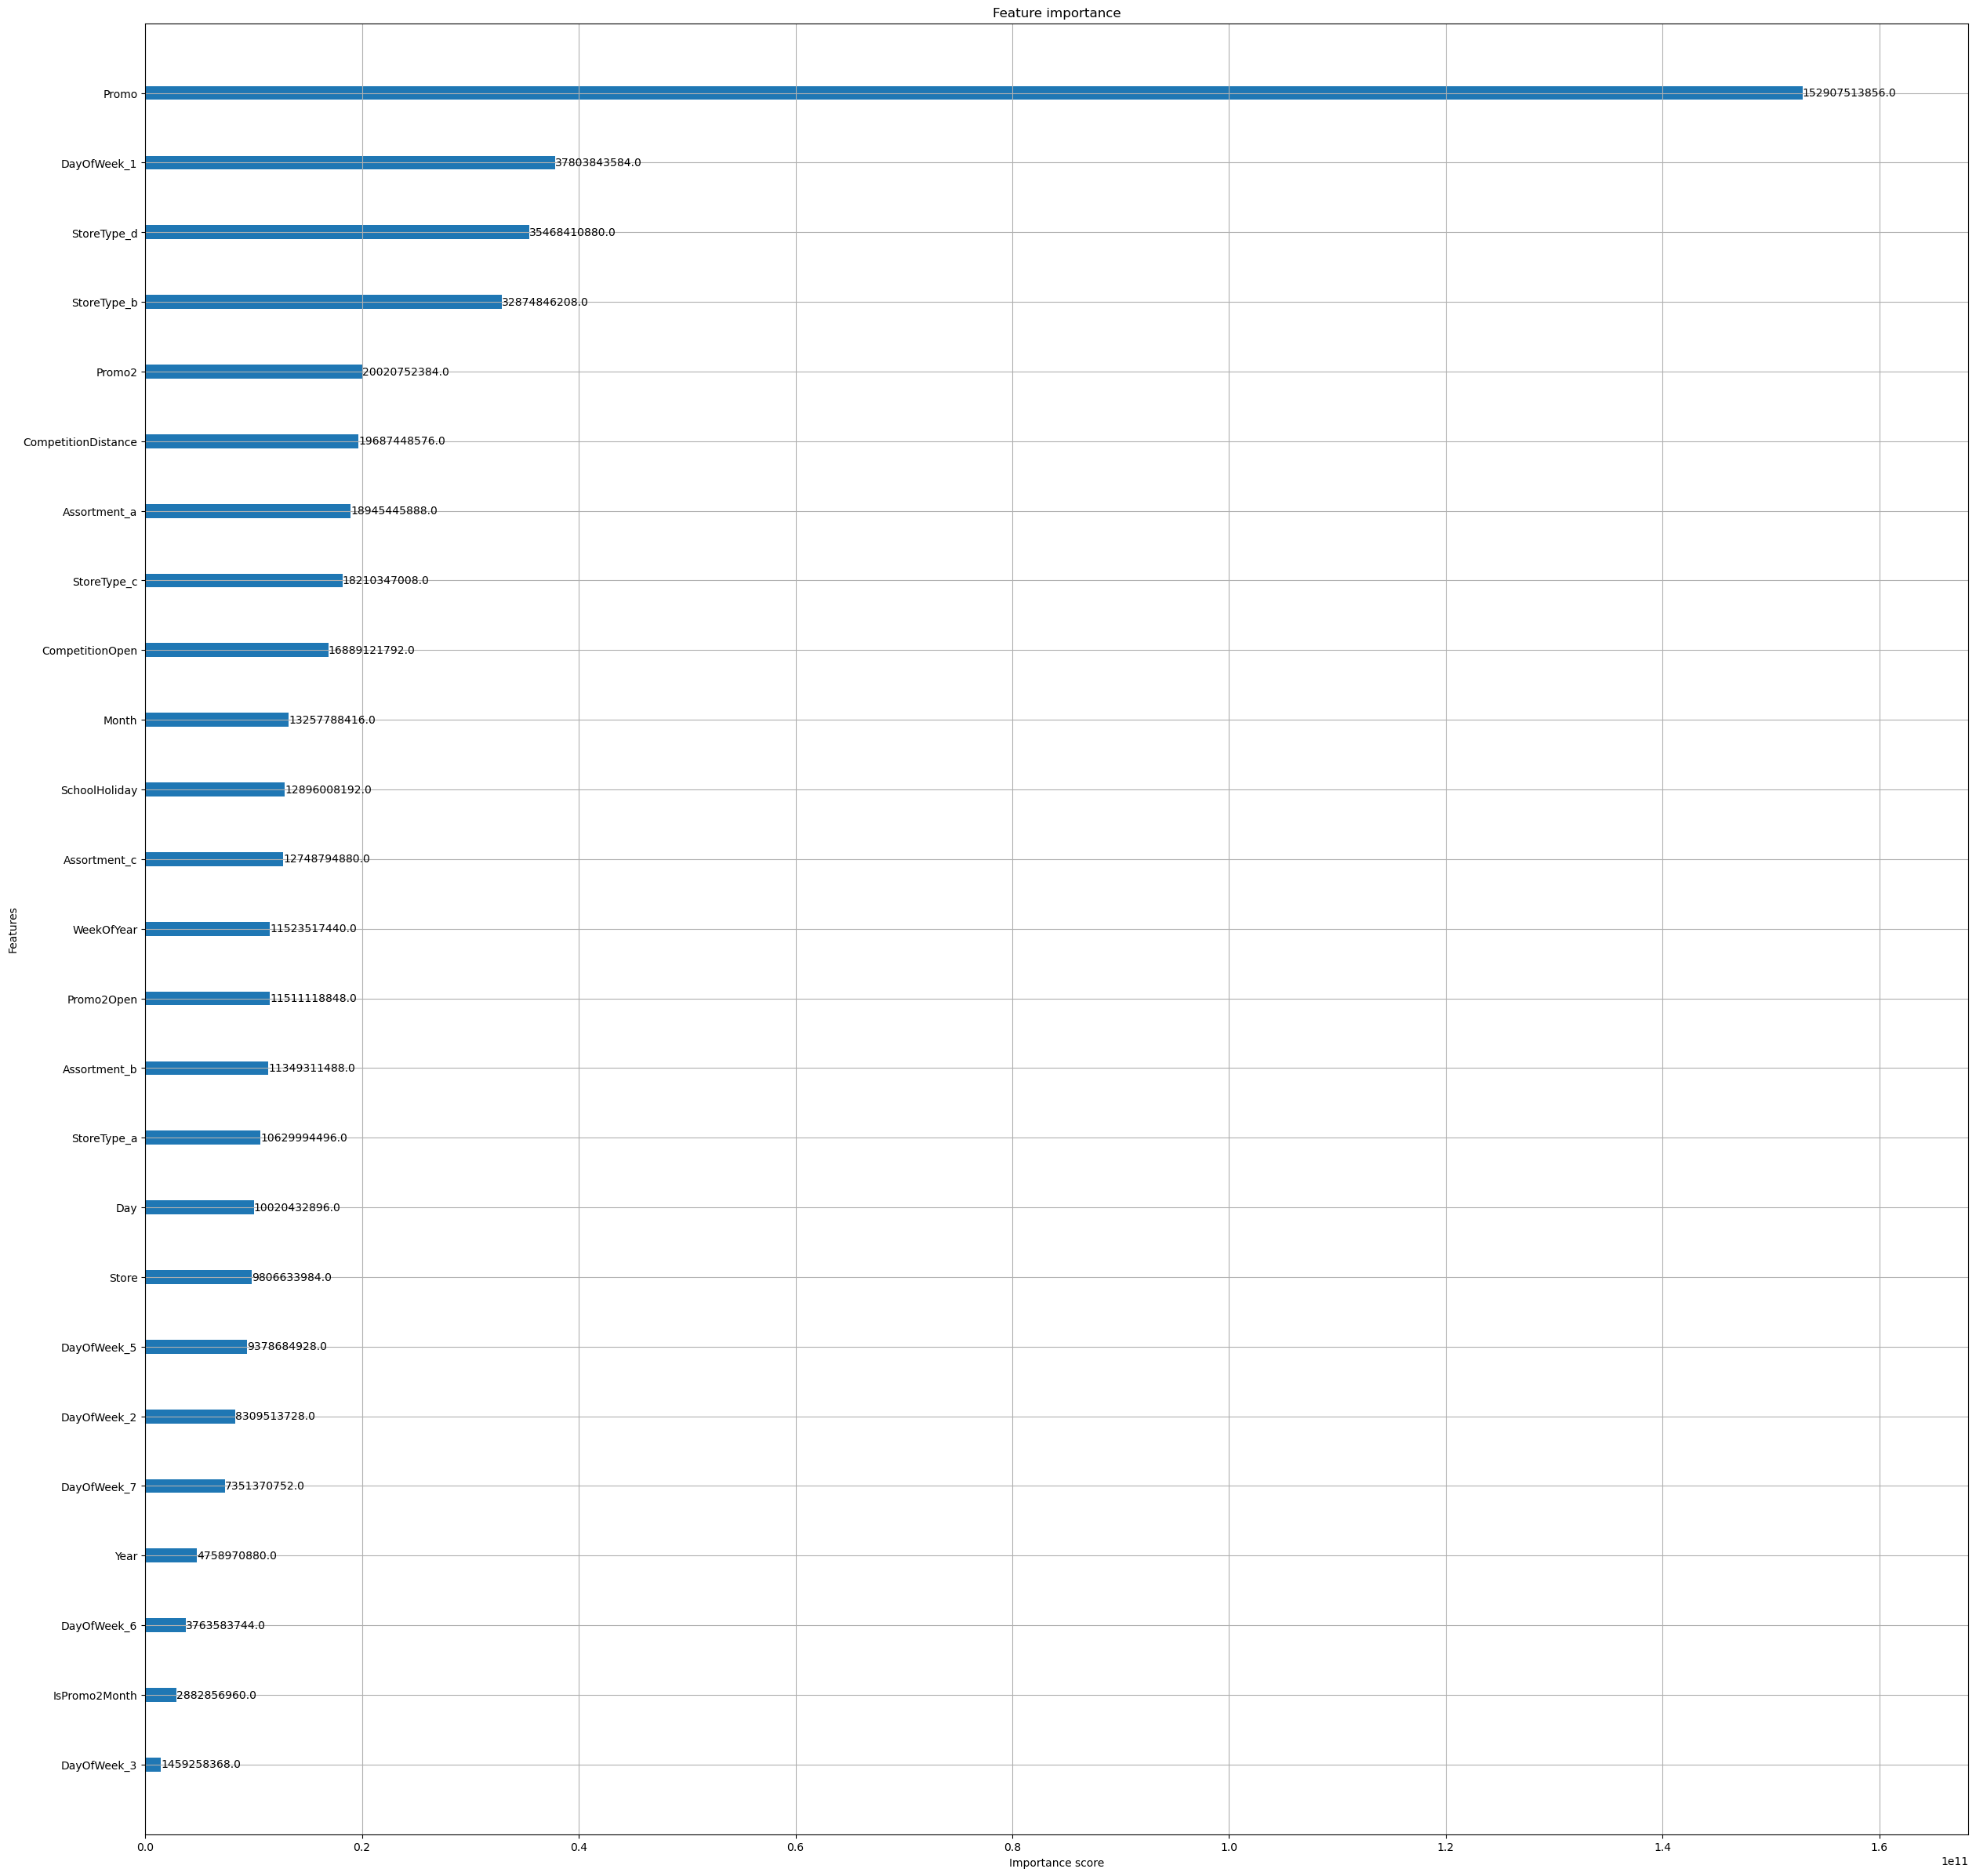

In [193]:
xgboost.plot_importance(model, importance_type='gain')
plt.show()

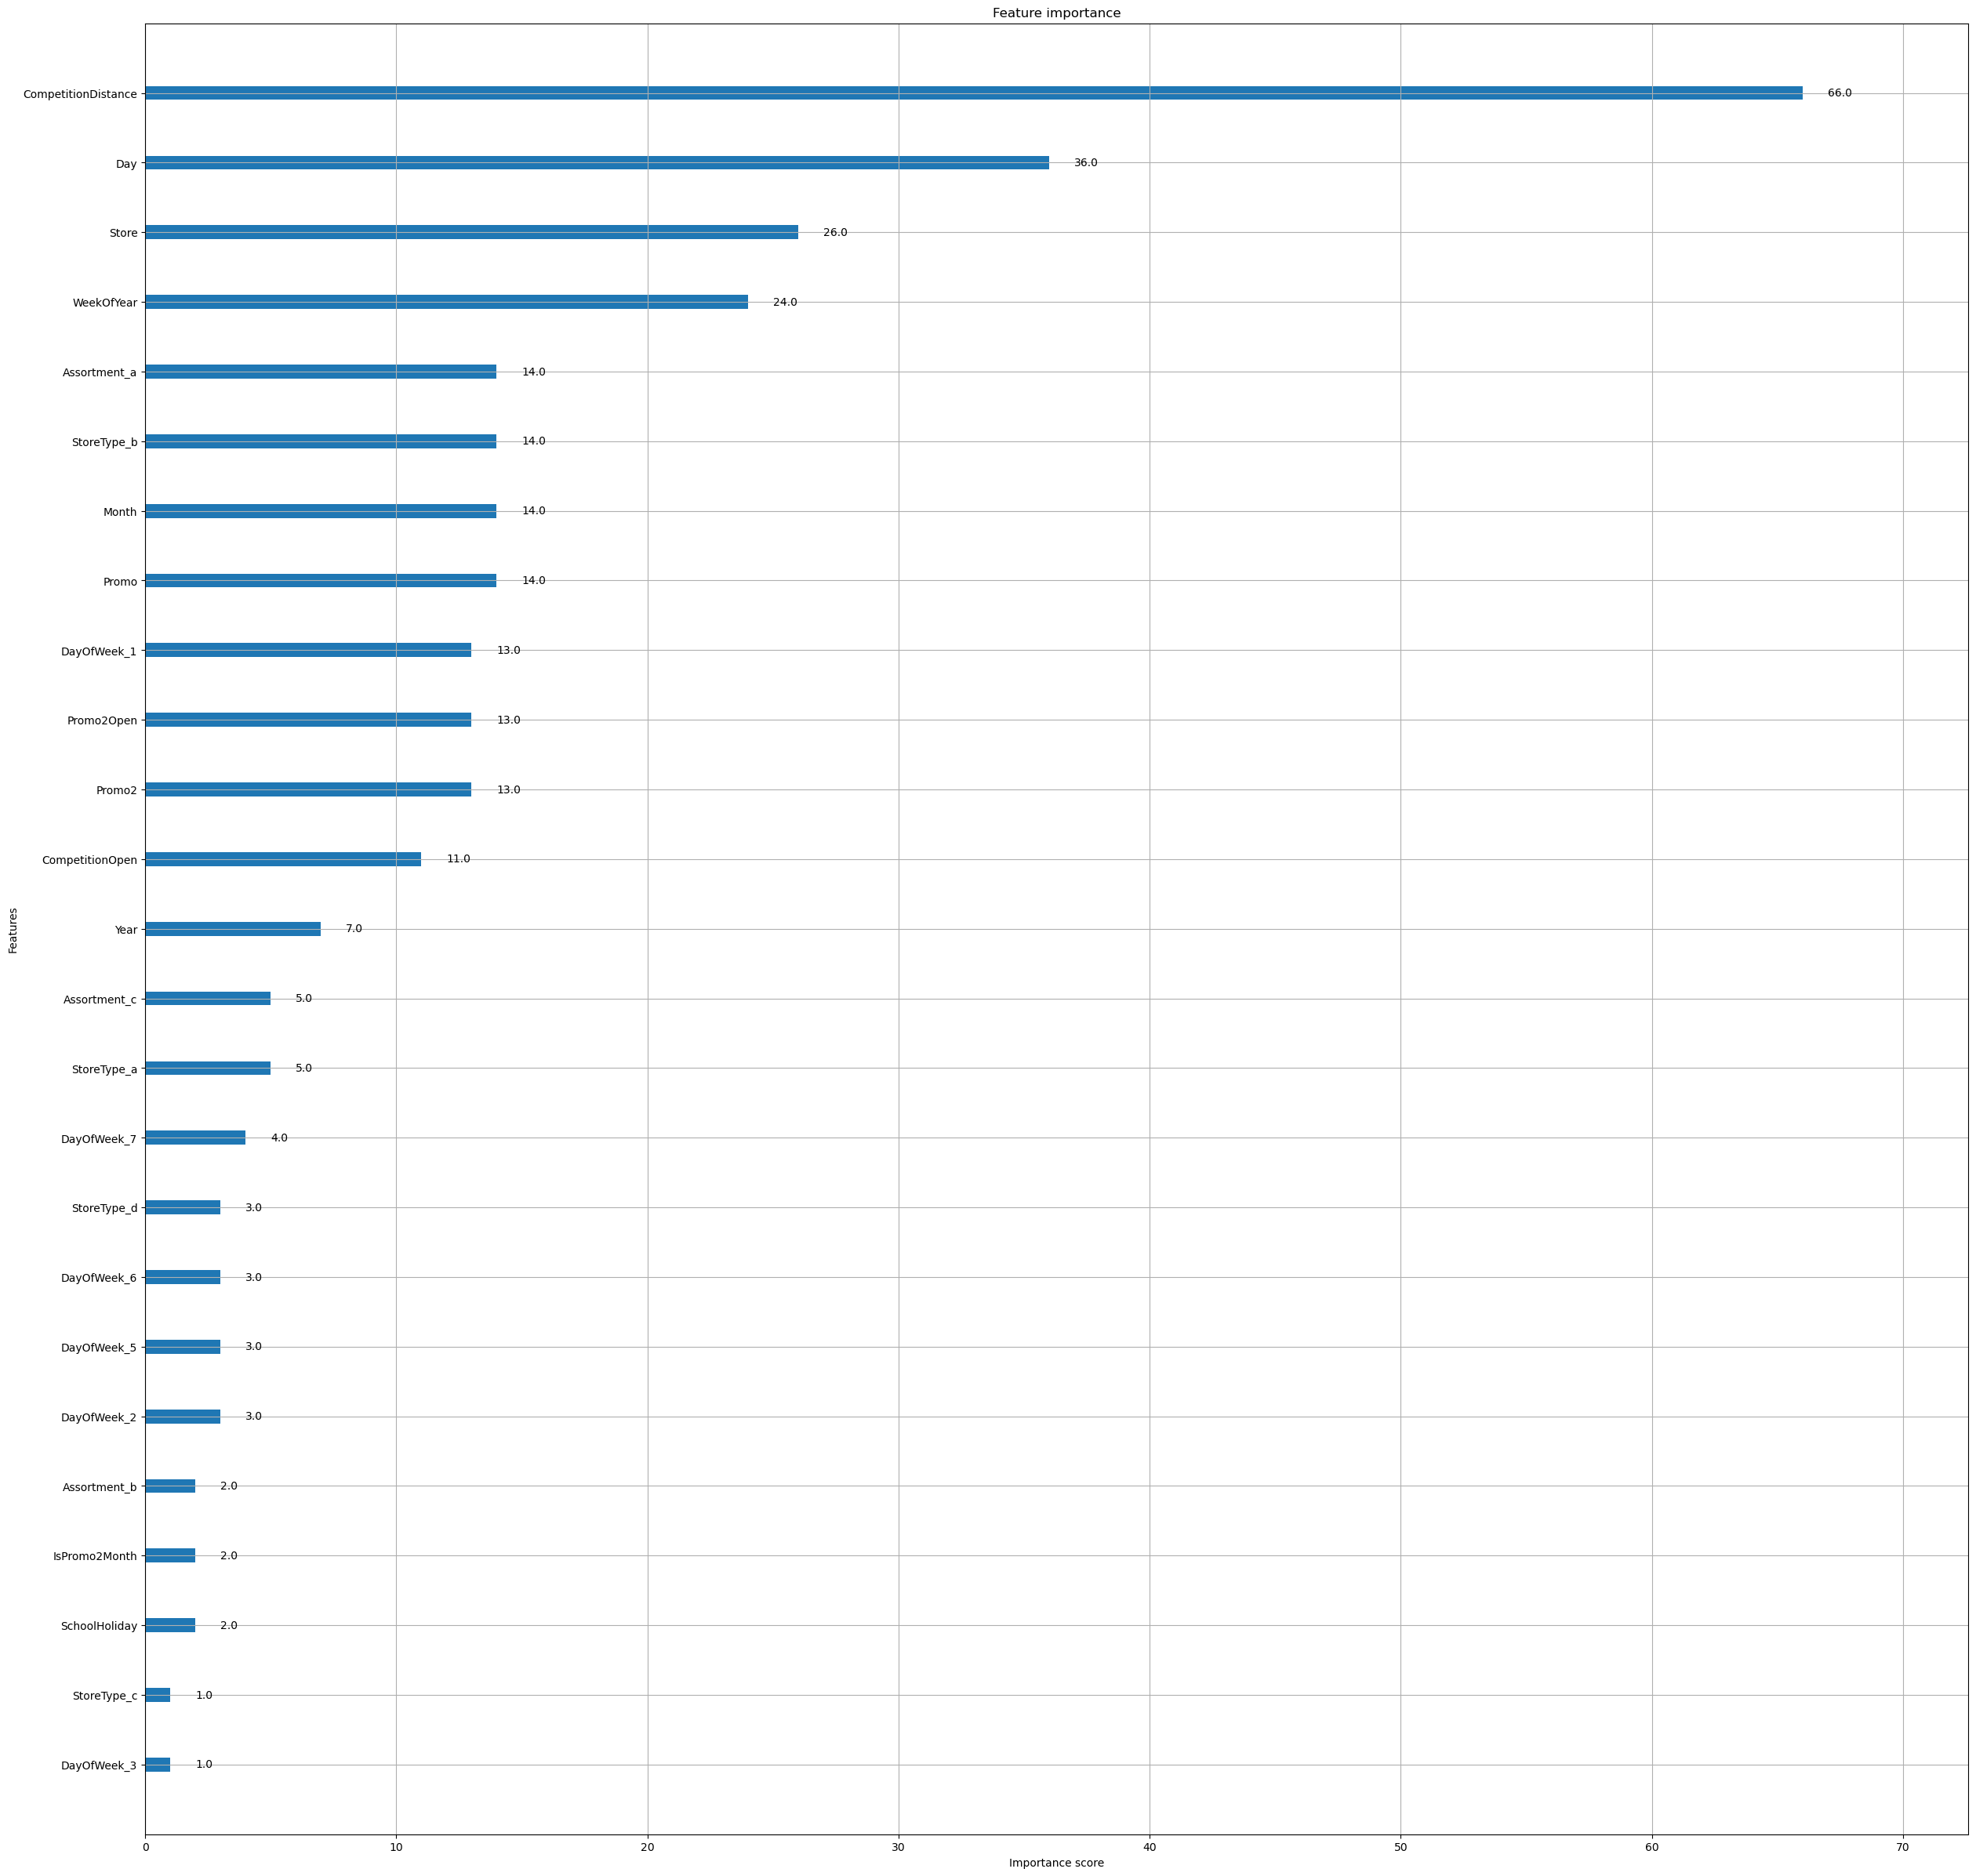

In [194]:
xgboost.plot_importance(model, importance_type='weight')
plt.show()

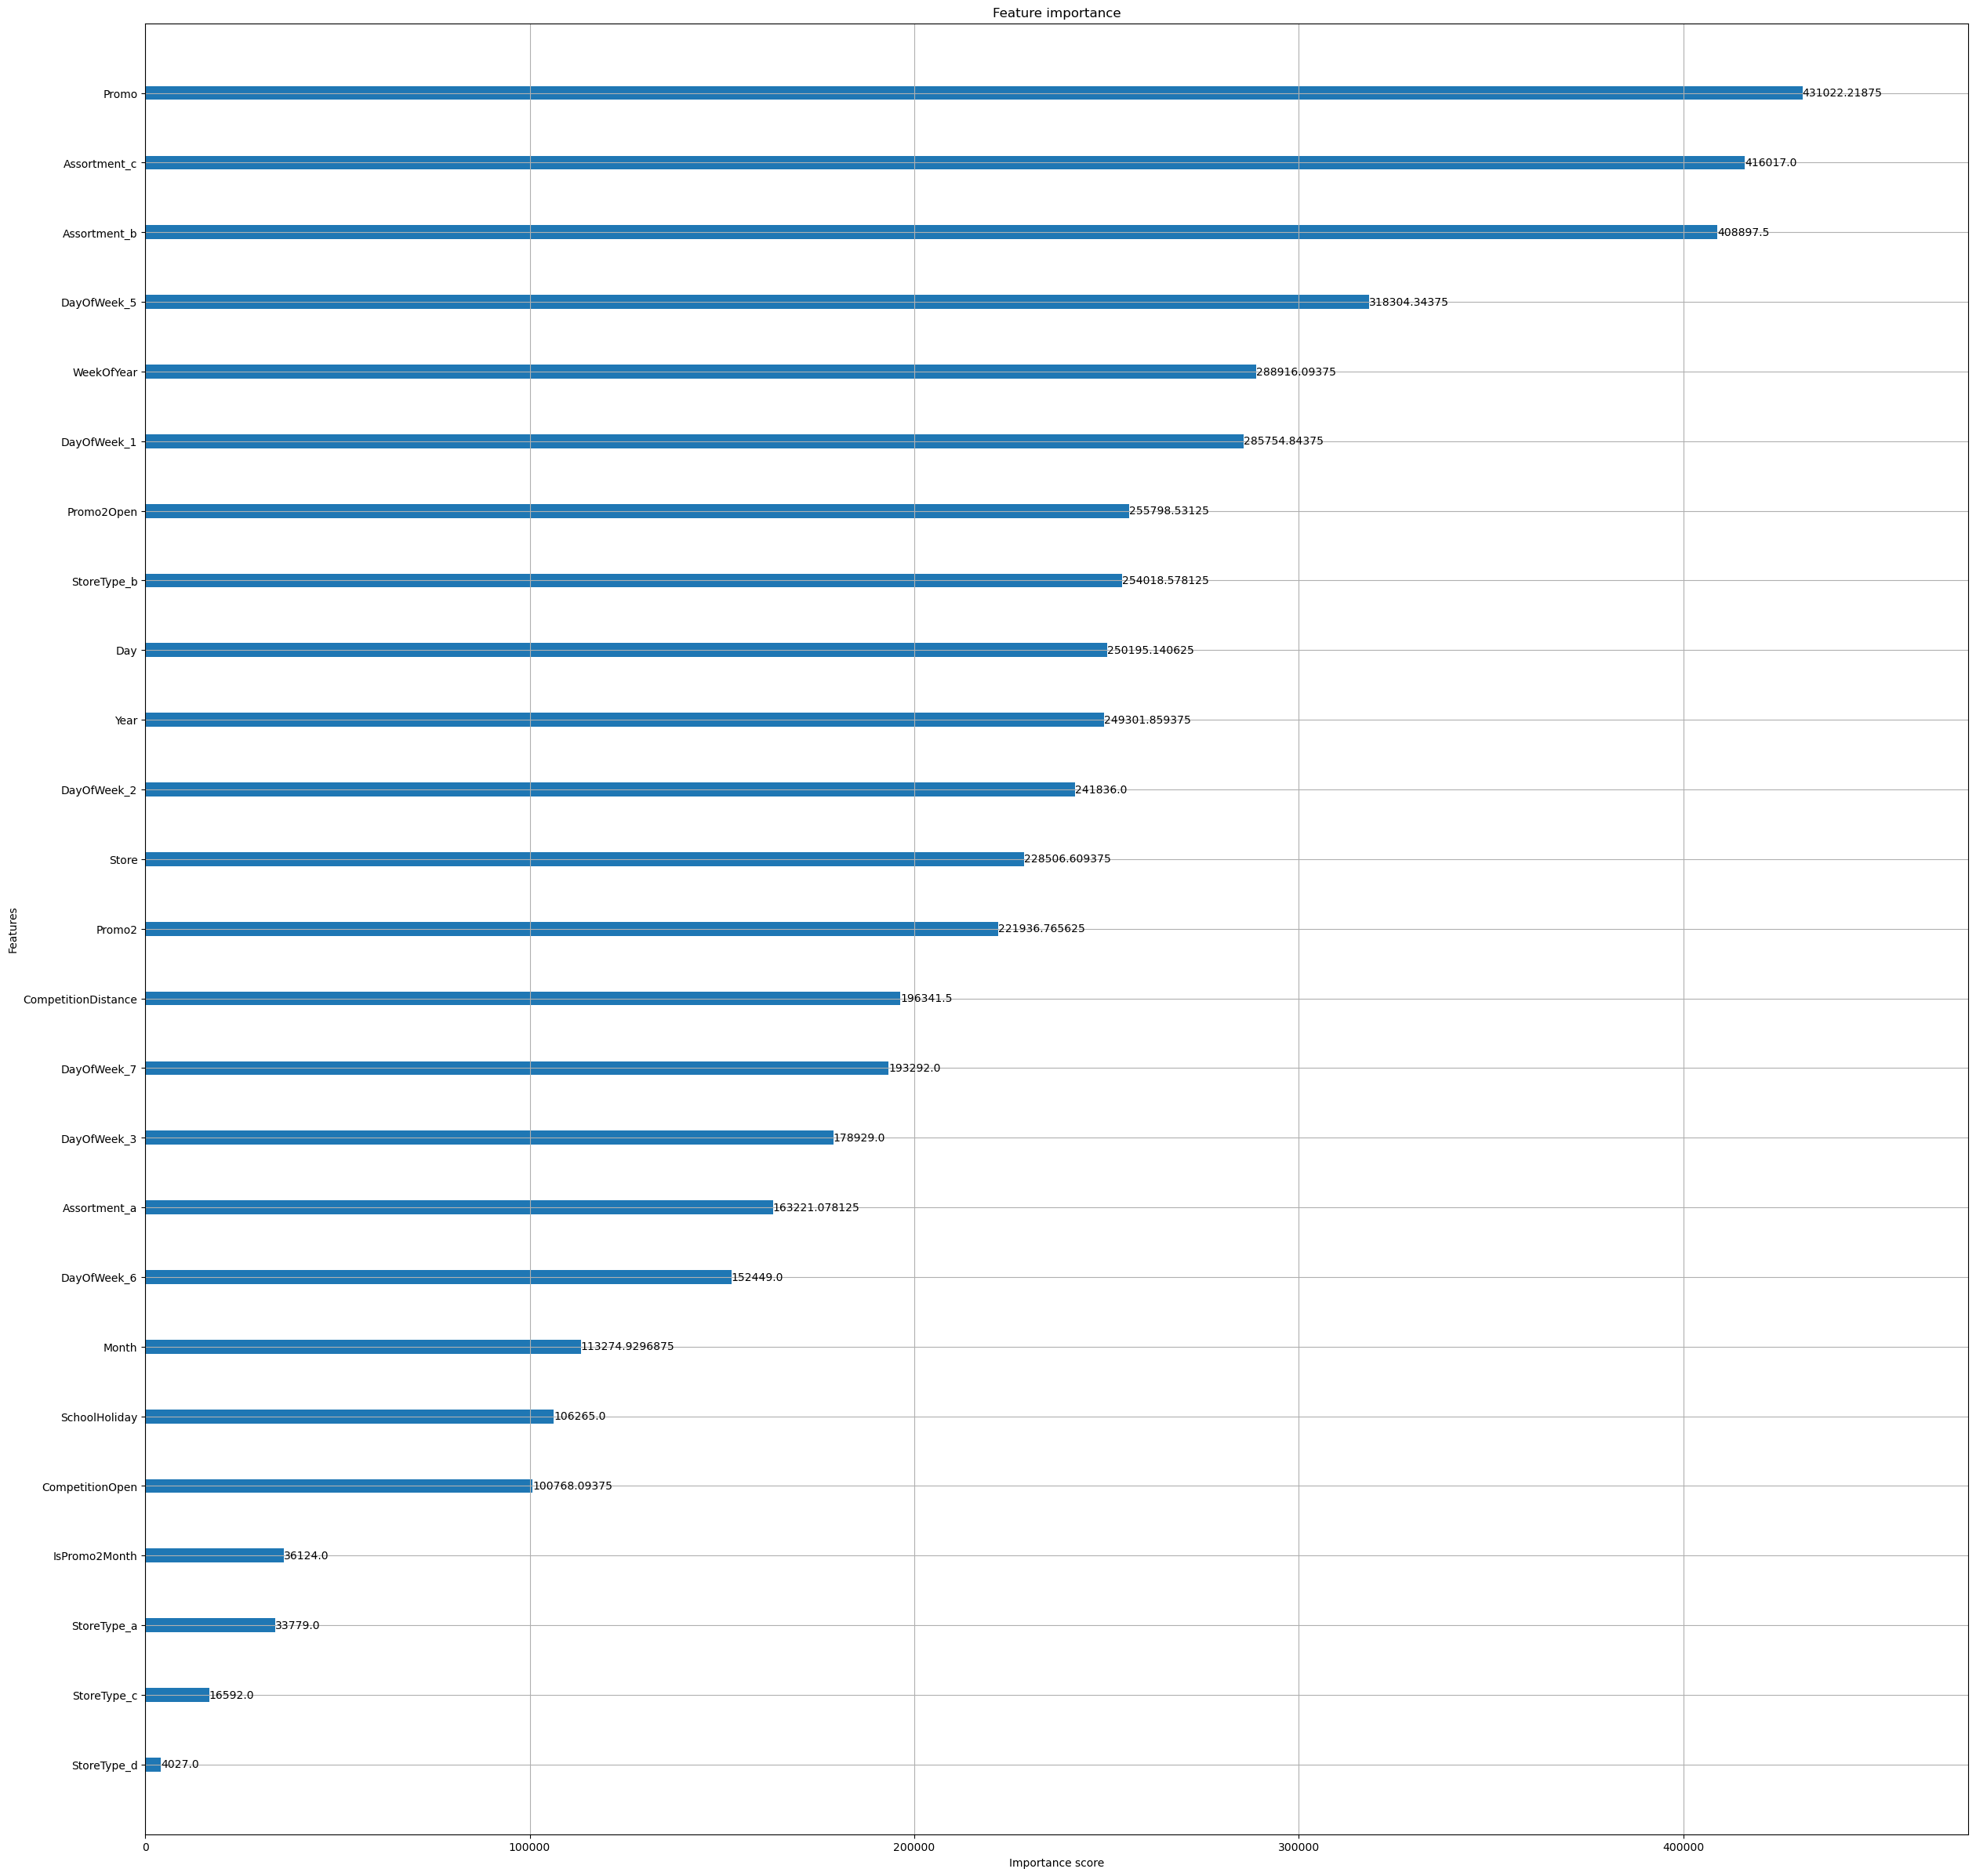

In [195]:
xgboost.plot_importance(model, importance_type='cover')
plt.show()

## K Fold Cross Validation

Notice that we didn't create a validation set before training our XGBoost model. We'll use a different validation strategy this time, called K-fold cross validation ([source](https://vitalflux.com/k-fold-cross-validation-python-example/)):

![](https://vitalflux.com/wp-content/uploads/2020/08/Screenshot-2020-08-15-at-11.13.53-AM.png)

- تستخدم في
1. تستخدم في ضبط المعلمات الفائقه
2. تستخدم للتجربه بين استراتيجيات النماذج المختلفه

- مفيد جدا ل
1. مجموعه البيانات الصغيره وليست مفيدة لمجموعه البيانات الكبيرة
2. قد لا تكون الاستراتيجيه المثاليه هنا  يجب ان تعكس البيانات الحياه الواقعيه التي سوف يراها النموذج (بيانات التحقق)
3. يجب ان تكون اقرب الى بيانات الاختبار ومجموعه الاختبار تحدث في المستقبل (بيانات التحقق)
4. يجب ان نفكر جيدا عند وجود بيانات وقت قد لا تكون هذه الاستراتيجيه مفيده هنا

In [199]:
from sklearn.model_selection import KFold

Let's define a helper function `train_and_evaluate` which trains a model the given parameters and returns the trained model, training error and validation error.

In [202]:
def train_and_evaluate(X_train, train_targets, X_val, val_targets, **params):
    model = XGBRegressor(random_state=42, n_jobs=-1, **params)
    model.fit(X_train, train_targets)
    train_rmse = root_mean_squared_error(model.predict(X_train), train_targets)
    val_rmse = root_mean_squared_error(model.predict(X_val), val_targets)
    return model, train_rmse, val_rmse

In [203]:
kfold = KFold(n_splits = 5, shuffle = True)
# shuffle=True يعني أن البيانات سيتم خلطها (shuffle) عشوائياً قبل تقسيمها إلى الطيات (folds).

In [205]:
models = []

for train_idxs, val_idxs in kfold.split(X):
    X_train, train_targets = X.iloc[train_idxs], targets.iloc[train_idxs]
    X_val, val_targets = X.iloc[val_idxs], targets.iloc[val_idxs]
    model, train_rmse, val_rmse = train_and_evaluate(X_train, 
                                                     train_targets, 
                                                     X_val, 
                                                     val_targets, 
                                                     max_depth=4, 
                                                     n_estimators=20)
    models.append(model)
    print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))

Train RMSE: 2394.306119258806, Validation RMSE: 2385.981635661229
Train RMSE: 2412.264852425302, Validation RMSE: 2426.522734229282
Train RMSE: 2366.1954102721566, Validation RMSE: 2353.447105915362
Train RMSE: 2369.034372269191, Validation RMSE: 2366.4668722278197
Train RMSE: 2384.042559469375, Validation RMSE: 2401.146657626747


Let's also define a function to average predictions from the 5 different models.

In [211]:
(models[0].predict(X)+models[1].predict(X)+models[2].predict(X)+models[3].predict(X)+models[4].predict(X))/5

array([ 7982.829 ,  7487.1084,  8437.079 , ...,  7409.4375,  7669.775 ,
       10437.773 ], dtype=float32)

In [212]:
def predict_avg(models, inputs):
    return np.mean([model.predict(inputs) for model in models], axis=0)
    # يقوم كل مودل بالتنبا ثم نحسب المتوسط لكل قيمه من المودل 

In [213]:
preds = predict_avg(models, X)
preds

array([ 7982.829 ,  7487.1084,  8437.079 , ...,  7409.4375,  7669.775 ,
       10437.773 ], dtype=float32)

We can now use `predict_avg` to make predictions for the test set.

In [215]:
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error

# تعريف النموذج
model = XGBRegressor(random_state=42, n_jobs=-1, max_depth=4, n_estimators=20)

kf = KFold(n_splits=5, shuffle=True)  # أضف random_state لتكرار نفس التقسيم

# استخدام cross_val_score مع KFold
scores = cross_val_score(model, X, targets, cv=kf, scoring='neg_mean_squared_error')
print("MSE for (KFold):", scores)

# تحويل القيم إلى موجبة ثم RMSE
mse_scores = -scores
rmse_scores = np.sqrt(mse_scores)

print("RMSE for (KFold):", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

# استخدام cross_val_predict مع KFold لتوقع القيم عبر الطيات
y_pred = cross_val_predict(model, X, targets, cv=kf)

# لحساب RMSE على التوقعات مجتمعة (اختياري)
overall_rmse = root_mean_squared_error(targets, y_pred)
print("RMSE cross_val_predict:", overall_rmse)

MSE for (KFold): [-5663073.47741771 -5753578.02600867 -5716722.65320626 -5761384.41670338
 -5747062.97735434]
RMSE for (KFold): [2379.72130247 2398.66171563 2390.96688668 2400.28840282 2397.30327188]
Mean RMSE: 2393.388315894029
RMSE cross_val_predict: 2377.9818842164445


In [216]:
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error

# تعريف النموذج
model = XGBRegressor(random_state=42, n_jobs=-1, max_depth=4, n_estimators=100)

kf = KFold(n_splits=5, shuffle=True)  # أضف random_state لتكرار نفس التقسيم

# استخدام cross_val_score مع KFold
scores = cross_val_score(model, X, targets, cv=kf, scoring='neg_mean_squared_error')
print("MSE for (KFold):", scores)

# تحويل القيم إلى موجبة ثم RMSE
mse_scores = -scores
rmse_scores = np.sqrt(mse_scores)

print("RMSE for (KFold):", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

# استخدام cross_val_predict مع KFold لتوقع القيم عبر الطيات
y_pred = cross_val_predict(model, X, targets, cv=kf)

# لحساب RMSE على التوقعات مجتمعة (اختياري)
overall_rmse = root_mean_squared_error(targets, y_pred)
print("RMSE cross_val_predict:", overall_rmse)

MSE for (KFold): [-3113461.61655407 -3033976.49836541 -2984308.18852014 -3139378.40411917
 -2962530.25696181]
RMSE for (KFold): [1764.50038724 1741.83136335 1727.51503279 1771.82911256 1721.20023732]
Mean RMSE: 1745.3752266531515
RMSE cross_val_predict: 1751.195736631488


## Hyperparameter Tuning and Regularization

Just like other machine learning models, there are several hyperparameters we can to adjust the capacity of model and reduce overfitting.

<img src="https://i.imgur.com/EJCrSZw.png" width="480">

Check out the following resources to learn more about hyperparameter supported by XGBoost:

- https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor
- https://xgboost.readthedocs.io/en/latest/parameter.html

In [218]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [219]:
XGBRegressor?

Init signature:
XGBRegressor(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'reg:squarederror',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost regression.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : typing.Optional[int]
        Number of gradient boosted trees.  Equivalent to number of boosting
        rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with hig

In [220]:
def test_params_kfold(n_splits, **params):
    train_rmses, val_rmses, models = [], [], []
    kfold = KFold(n_splits, shuffle=True)
    for train_idxs, val_idxs in kfold.split(X):
        X_train, train_targets = X.iloc[train_idxs], targets.iloc[train_idxs]
        X_val, val_targets = X.iloc[val_idxs], targets.iloc[val_idxs]
        model, train_rmse, val_rmse = train_and_evaluate(X_train, train_targets, X_val, val_targets, **params)
        models.append(model)
        train_rmses.append(train_rmse)
        val_rmses.append(val_rmse)
    print('Train RMSE: {}, Validation RMSE: {}'.format(np.mean(train_rmses), np.mean(val_rmses)))
    return models

Since it may take a long time to perform 5-fold cross validation for each set of parameters we wish to try, we'll just pick a random 10% sample of the dataset as the validation set.

In [222]:
test_params_kfold(5, n_estimators = 100)

Train RMSE: 1172.0252122632737, Validation RMSE: 1183.0099090242234


[XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...),
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, e

In [223]:
from sklearn.model_selection import train_test_split

In [224]:
X_train, X_val, train_targets, val_targets = train_test_split(X, targets, test_size = 0.1)

In [225]:
def test_params(**params):
    model = XGBRegressor(n_jobs=-1, random_state=42, **params)
    model.fit(X_train, train_targets)
    train_rmse = root_mean_squared_error(model.predict(X_train), train_targets)
    val_rmse = root_mean_squared_error(model.predict(X_val), val_targets)
    print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))

# 1. n_estimators

- نتوقف عندما نرى ان زياده يؤدي الى انخفاض طفيف في الخساره او زيادتها وهو شيء لا يذكر لذالك نتوقف وزيادته قد تؤدي الى الافراط في التعلم

In [216]:
test_params(n_estimators = 10)

Train RMSE: 2293.1883519033604, Validation RMSE: 2271.677477964527


In [217]:
test_params(n_estimators = 20)

Train RMSE: 2054.4002711238318, Validation RMSE: 2036.2147855457733


In [203]:
test_params(n_estimators = 100)

Train RMSE: 1164.0627228413894, Validation RMSE: 1171.4057764998731


In [204]:
test_params(n_estimators = 240)

Train RMSE: 900.517577843738, Validation RMSE: 913.7713231143908


In [205]:
test_params(n_estimators = 5000)

Train RMSE: 490.45183969106915, Validation RMSE: 642.3910090746161


In [206]:
test_params(n_estimators = 10000)

Train RMSE: 416.25399543705436, Validation RMSE: 638.5793088290612


> **EXERCISE**: Experiment with different values of `n_estimators`, plot a graph of the training and validation error and determine the best value for `n_estimators`.
> 
> <img src="https://i.imgur.com/EJCrSZw.png" width="360">

In [208]:
n_values = []
n = 100
while n < 4000 :
    n_values.append(n)
    n += 100
errors_df = pd.DataFrame([test_params(n, n_estimators = n) for n in n_values])
errors_df

TypeError: test_params() takes 0 positional arguments but 1 was given

In [ ]:
errors_df

In [219]:
plt.figure(figsize = (20,6))
plt.plot(errors_df['n_estimators'], errors_df['train_rmse'])
plt.plot(errors_df['n_estimators'], errors_df['val_rmse'])
plt.title('Training vs. Validation Error')
plt.xticks()
plt.xlabel('n_estimators')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.show()

NameError: name 'errors_df' is not defined

<Figure size 2000x600 with 0 Axes>

# 2. max_depth

As you increase the max depth of each tree, the capacity of the tree increases and it can capture more information about the training set.

In [ ]:
def max_depth_error(md):
    
    model = XGBRegressor(max_depth = md, random_state = 42, n_jobs = -1)
    model.fit(X_train, train_targets)
    train_acc = 1 - model.score(X_train, train_targets)
    val_acc = 1 - model.score(X_val, val_targets)
    return{'Max depth' : md, 'Training Error' : train_acc, 'Validation Error' : val_acc}
    
errors_df_depth = pd.DataFrame([max_depth_error(md) for md in range(1, 20)])
errors_df_depth

In [ ]:
plt.figure(figsize = (20, 8))
plt.plot(errors_df_depth['Max depth'], errors_df_depth['Training Error'])
plt.plot(errors_df_depth['Max depth'], errors_df_depth['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(1, 40, 1))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.grid()
plt.show()

In [457]:
test_params(max_depth = 2)

Train RMSE: 2384.6143768830643, Validation RMSE: 2386.6972235460507


In [458]:
test_params(max_depth = 5)

Train RMSE: 1433.260121523341, Validation RMSE: 1438.1107779683116


In [490]:
test_params(max_depth = 10, n_estimators = 300) #best

Train RMSE: 474.9639607466109, Validation RMSE: 699.4468591111375


In [447]:
test_params(max_depth = 2, n_estimators = 1600)

Train RMSE: 1731.8615192483398, Validation RMSE: 1736.9767851304423


In [448]:
test_params(max_depth = 5, n_estimators = 1600)

Train RMSE: 714.0357346476493, Validation RMSE: 757.2566329250808


In [449]:
test_params(max_depth = 10, n_estimators = 1600)

Train RMSE: 206.25661112910535, Validation RMSE: 688.5744833352765


In [455]:
test_params(max_depth = 11, n_estimators = 1600)

Train RMSE: 114.63498907652836, Validation RMSE: 705.9192200282974


> **EXERCISE**: Experiment with different values of `max_depth`, plot a graph of the training and validation error and determine the optimal.
> 
> <img src="https://i.imgur.com/EJCrSZw.png" width="360">

#### 3. `learning_rate`
- هو  alpha
- The scaling factor to be applied to the prediction of each tree. A very high learning rate (close to 1) will lead to overfitting, and a low learning rate (close to 0) will lead to underfitting.

In [505]:
test_params(learning_rate=0.01)

Train RMSE: 2633.6963417249603, Validation RMSE: 2636.1880583436537


In [507]:
test_params(learning_rate=0.1)

Train RMSE: 1878.5124185637796, Validation RMSE: 1884.6068263865104


In [509]:
test_params(learning_rate=0.3)

Train RMSE: 1156.3832208783904, Validation RMSE: 1167.4862093219533


In [501]:
test_params(learning_rate=0.5)

Train RMSE: 1016.4338906038518, Validation RMSE: 1031.4654461726823


In [517]:
test_params(learning_rate=0.7)

Train RMSE: 963.7088137680865, Validation RMSE: 985.3132799361454


In [519]:
test_params(learning_rate=0.9)

Train RMSE: 954.873380666619, Validation RMSE: 984.8825276377866


In [523]:
test_params(learning_rate=1)

Train RMSE: 997.112753643148, Validation RMSE: 1025.0505823498513


In [543]:
test_params(max_depth = 9, n_estimators = 300, learning_rate=0.6)

Train RMSE: 490.35455371553576, Validation RMSE: 729.0868934265642


In [575]:
test_params(max_depth = 10, n_estimators = 240, learning_rate=0.3)

Train RMSE: 507.84773501919454, Validation RMSE: 706.3106273021255


In [210]:
%%time
from sklearn.model_selection import GridSearchCV

# النموذج الأساسي
xgb = XGBRegressor(n_jobs=-1, random_state=42)

# شبكة البحث
param_grid = {
    'max_depth': [i for i in range(1,12)],
    'n_estimators': [50,100,150,200, 240, 280,300],
    'learning_rate': [0.1, 0.2, 0.3,0.4,0.5,0.6,0.7,0.8,0.9]
}

# تهيئة GridSearchCV
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=3)

# fit على بياناتك (مثال: X_train, y_train)
grid_search.fit(X_train, train_targets)

# أفضل المعاملات
print("Best params:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)


Fitting 3 folds for each of 693 candidates, totalling 2079 fits
[CV 1/3] END learning_rate=0.1, max_depth=1, n_estimators=50;, score=-2819.130 total time=   0.6s
[CV 2/3] END learning_rate=0.1, max_depth=1, n_estimators=50;, score=-2809.983 total time=   0.7s
[CV 3/3] END learning_rate=0.1, max_depth=1, n_estimators=50;, score=-2690.697 total time=   0.8s
[CV 1/3] END learning_rate=0.1, max_depth=1, n_estimators=100;, score=-2750.719 total time=   1.5s
[CV 2/3] END learning_rate=0.1, max_depth=1, n_estimators=100;, score=-2741.276 total time=   1.3s
[CV 3/3] END learning_rate=0.1, max_depth=1, n_estimators=100;, score=-2644.741 total time=   1.3s
[CV 1/3] END learning_rate=0.1, max_depth=1, n_estimators=150;, score=-2721.233 total time=   1.6s
[CV 2/3] END learning_rate=0.1, max_depth=1, n_estimators=150;, score=-2710.675 total time=   1.4s
[CV 3/3] END learning_rate=0.1, max_depth=1, n_estimators=150;, score=-2627.645 total time=   1.4s
[CV 1/3] END learning_rate=0.1, max_depth=1, n_e

In [212]:
models = []

for train_idxs, val_idxs in kfold.split(X):
    X_train, train_targets = X.iloc[train_idxs], targets.iloc[train_idxs]
    X_val, val_targets = X.iloc[val_idxs], targets.iloc[val_idxs]
    model, train_rmse, val_rmse = train_and_evaluate(X_train, 
                                                     train_targets, 
                                                     X_val, 
                                                     val_targets, 
                                                     max_depth=9, 
                                                     n_estimators=300,
                                                    learning_rate=0.2)
    models.append(model)
    print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))

Train RMSE: 616.5389549631079, Validation RMSE: 721.3511971561463
Train RMSE: 612.3629123062917, Validation RMSE: 725.7308784706773
Train RMSE: 616.1172668636603, Validation RMSE: 725.3942670725108
Train RMSE: 611.9230244662151, Validation RMSE: 718.4790975470614
Train RMSE: 616.6431376914146, Validation RMSE: 723.9635599266302


In [213]:
test_params(max_depth=9, n_estimators=300, learning_rate=0.2)

Train RMSE: 616.6431376914146, Validation RMSE: 723.9635599266302


In [220]:
test_params_kfold(5, n_estimators=300, learning_rate=0.2, max_depth=9)

Train RMSE: 613.9283579649211, Validation RMSE: 722.0567719716764


[XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...),
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_

# - وجود معلمه فائقه واحده فقط قد لا يحدث الافراط في التعلم لكن وجود اكثر قد يحدث
# - يمكن البدا مع المعلمات الفائقه التي سيكون لها التاثير الكبير والتي تكون اكثر فاعلية
# - يمكت معرفه المعلمات الاكثر فاعليه من خلال تجربه قيمتين لها ونرى تاثيرها الكبير عليهم

#### 4. `booster`

Instead of using Decision Trees, XGBoost can also train a linear model for each iteration. This can be configured using `booster`.

In [248]:
test_params(booster ='gblinear')

Train RMSE: 2728.5472580451938, Validation RMSE: 2722.3111801495475


In [255]:
test_params(booster ='gbtree')

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


In [257]:
test_params(booster ='dart')

Train RMSE: 1164.1345610410265, Validation RMSE: 1170.5711245048087


Clearly, a linear model is not well suited for this dataset.

> **EXERCISE**: Exeperiment with other hyperparameters like `gamma`, `min_child_weight`, `max_delta_step`, `subsample`, `colsample_bytree` etc. and find their optimal values. Learn more about them here: https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor

#### 5. `subsample`
- نسبة العينات التي تُستخدم لتدريب كل شجرة. يقلل هذا من الافراط في التعلم عن طريق أخذ عينات عشوائية
- القيم النموذجية: من 0.5 إلى 1.0.
 - عادةً تبدأ بـ 0.8 أو 0.9 لتقليل overfitting.

In [264]:
test_params(subsample=0.1)

Train RMSE: 1264.72393439889, Validation RMSE: 1274.661489161121


In [266]:
test_params(subsample=0.5)

Train RMSE: 1159.69925132794, Validation RMSE: 1167.8479823273228


In [273]:
test_params(subsample=0.9)

Train RMSE: 1169.194734345033, Validation RMSE: 1176.703751256129


In [275]:
test_params(subsample=1) # same default

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


#### 6. `colsample_bytree`
-  نسبة الميزات (الأعمدة) التي تُستخدم لكل شجرة. يساعد في جعل النموذج أكثر تعميمًا ويقلل من الافراط في التعلم
- القيم النموذجية: من 0.5 إلى 1.0.  
- أيضاً يبدأ عند 0.8 أو 0.9.

In [279]:
test_params(colsample_bytree=0.1)

Train RMSE: 2161.87250485743, Validation RMSE: 2162.677510406613


In [281]:
test_params(colsample_bytree=0.5)

Train RMSE: 1309.09537537681, Validation RMSE: 1318.3146063118297


In [283]:
test_params(colsample_bytree=0.9)

Train RMSE: 1167.3838229793937, Validation RMSE: 1173.1262904193047


In [285]:
test_params(colsample_bytree=1) # same default

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


#### 8. `gamma`
- الحد الأدنى لنقص الخسارة المطلوبة لإجراء تقسيم جديد على الشجرة. قيم أعلى تعني أن النموذج يحتاج لشروط أقوى لتقسيم الشجرة، مما يقلل التعقيد ويكافح الافراط في التعلم
- القيم النموذجية: 0 إلى 5.  
- قيمة 0 تعني عدم وجود تنظيم إضافي. ابدأ بـ 0 وجرب قيم أعلى إذا لاحظت وجود افراط في التعلم

In [288]:
test_params(gamma=0)

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


In [290]:
test_params(gamma=5)

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


In [304]:
test_params(gamma=9)

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


#### 9. `min_child_weight`
- الحد الأدنى لمجموع أوزان العينات المطلوبة في العقدة الفرعية. يشبه ضبط حساسية النموذج تجاه النقاط القليلة في البيانات.
- القيم النموذجية: 1 إلى 10.  
- زيادة القيمة تجعل النموذج أكثر تحفظاً (قليل الانقسام في الأشجار).

In [296]:
test_params(min_child_weight=1)

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


In [298]:
test_params(min_child_weight=5)

Train RMSE: 1172.3560316867963, Validation RMSE: 1178.8947510498751


In [308]:
test_params(min_child_weight=10)

Train RMSE: 1164.127956787099, Validation RMSE: 1173.3661982039646


#### 10. `reg_alpha (L1 regularization) و reg_lambda (L2 regularization) `
- معاملات تنظيم تساعد في تقليل التعقيد وتجنب الافراط في التعلم
  
- reg_alpha = عقوبة تشجع النموذج على استخدام عدد أقل من الميزات (تصفير بعض العوامل).
- القيم النموذجية تبدأ من 0 (تعني لا يوجد تنظيم L1) وتصل إلى 1 أو أكثر.  
 - في بعض الحالات، يمكن تجرب قيم أعلى مثل 5 أو 10 إذا كنت تريد تنظيم أقوى يقلل من تعقيد النموذج
  .
- reg_lambda = عقوبة تقلل من القيم الكبيرة للمعاملات وتحسن استقرار النموذ
 - تبدأ القيمة الافتراضية بـ 1.0.    - يمكنك تجرب زيادة هذه القيمة إلى 10 أو حتى أكثر إذا كان النموذج يعاني مالافراط في التعلم 
  - قيم أقل من 1 تعني تنظيم أقل.g.

In [318]:
test_params(reg_alpha=0) # same default

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


In [320]:
test_params(reg_alpha=5) 

Train RMSE: 1164.137401377634, Validation RMSE: 1170.5728651179018


In [322]:
test_params(reg_alpha=10) 

Train RMSE: 1174.4145777215265, Validation RMSE: 1181.7986912552735


In [325]:
test_params(reg_lambda=1)

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


In [327]:
test_params(reg_lambda=5)

Train RMSE: 1182.9044952910006, Validation RMSE: 1191.2237026099647


In [331]:
test_params(reg_lambda=10)

Train RMSE: 1175.4378699373176, Validation RMSE: 1181.2251372528058


In [271]:
test_params()

Train RMSE: 1164.134570037447, Validation RMSE: 1170.5711364279673


> **EXERCISE**: Train a model with your best hyperparmeters and evaluate its peformance using 5-fold cross validation.

In [227]:
XGBRegressor?

Init signature:
XGBRegressor(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'reg:squarederror',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost regression.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : typing.Optional[int]
        Number of gradient boosted trees.  Equivalent to number of boosting
        rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with hig

In [280]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'reg:squarederror',  # هدف الانحدار
        'eval_metric': 'rmse',  # مقياس جذور متوسط الخطأ التربيعي
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
    }

    model = XGBRegressor(**param, early_stopping_rounds=20)
    model.fit(
        X_train, train_targets,
        eval_set=[(X_val, val_targets)],
        
        verbose=False
    )
    preds = model.predict(X_val)
    mse = mean_squared_error(val_targets, preds)
    # optuna يحاول تعظيم القيمة لذا نعيد القيمة السالبة لـ MSE للتصغير
    return -mse

study = optuna.create_study(direction='maximize')  # لأننا نُعيد سالب MSE
study.optimize(objective, n_trials=50)

print("أفضل المعاملات:", study.best_params)
print("أفضل قيمة MSE:", -study.best_value)


[I 2025-07-20 00:31:16,790] A new study created in memory with name: no-name-c374636a-f645-4b26-9456-0aa2f8a80f63
[I 2025-07-20 00:31:25,580] Trial 0 finished with value: -3804388.0769842435 and parameters: {'max_depth': 4, 'learning_rate': 0.09409219339722814, 'n_estimators': 239, 'subsample': 0.6562825909326341, 'colsample_bytree': 0.9468210208165921, 'gamma': 1.3612303401024584, 'min_child_weight': 6, 'reg_alpha': 0.5061437510733906, 'reg_lambda': 0.7093379230087621}. Best is trial 0 with value: -3804388.0769842435.
[I 2025-07-20 00:31:34,271] Trial 1 finished with value: -4468704.143411949 and parameters: {'max_depth': 9, 'learning_rate': 0.02300536066652059, 'n_estimators': 112, 'subsample': 0.6580987403635459, 'colsample_bytree': 0.8905270555851941, 'gamma': 0.31773749034196497, 'min_child_weight': 7, 'reg_alpha': 0.7631580076868205, 'reg_lambda': 0.3890551315809525}. Best is trial 0 with value: -3804388.0769842435.
[I 2025-07-20 00:31:41,324] Trial 2 finished with value: -695005

أفضل المعاملات: {'max_depth': 10, 'learning_rate': 0.23317371204016232, 'n_estimators': 438, 'subsample': 0.9597846396350116, 'colsample_bytree': 0.9894728394855957, 'gamma': 3.824537752091721, 'min_child_weight': 3, 'reg_alpha': 0.9297243558326596, 'reg_lambda': 0.053767687826810635}
أفضل قيمة MSE: 444967.336177109


## Putting it Together and Making Predictions

- Let's train a final model on the entire training set with custom hyperparameters.
- بعد الانتهاء من تحديد افضل المعلمات يمكن تدريب المودل على بيانات التدريب كامله من بينها بيانات التدريب والتحقق معا

In [ ]:
test_params(n_estimators=1000, learning_rate=0.2, max_depth=10, subsample=0.9, colsample_bytree=0.7)

In [ ]:
model = XGBRegressor(n_jobs=-1, random_state=42, n_estimators=1000, 
                     learning_rate=0.2, max_depth=10, subsample=0.9, 
                     colsample_bytree=0.7)

In [ ]:
%%time
model.fit(X, targets)

In [ ]:
root_mean_squared_error(targets, model.predict(X))

In [ ]:
model.score(X, targets)

In [ ]:
test_preds = model.predict(X_test)

In [ ]:
test_preds

In [ ]:
submission_df_XGboost = pd.DataFrame({
    'Id' : [i for i in range(1,41089)],
    'Sales' : test_preds
})

In [ ]:
test_df.isnull().sum()

In [ ]:
submission_df_XGboost['Sales'] = submission_df['Sales'] * test_df.Open.fillna(1.)

In [ ]:
submission_df_XGboost

In [ ]:
submission_df_XGboost.to_csv('submission_df_XGboost.csv', index = None)

In [ ]:
from IPython.display import FileLink

In [ ]:
FileLink('submission_df_XGboost.csv')